<a href="https://colab.research.google.com/github/ColeDeBois/Altmanlab/blob/main/Analysis_241003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount the Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# The code below sets the initial conditions and creates functions that are used later

In [16]:
# import libraries
from __future__ import division
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.optimize import curve_fit
from scipy import signal
import warnings
# warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)
# from tkinter import filedialog
from scipy.signal import welch #, hamming
from scipy.fft import fft, fftfreq
# import glob
# import tkinter

# define constants
fs = 50000  # data collection rate
dt = 1/fs
kBT = 4.11e-21     # room temp (J)
#eta = 0.001  # Pa s, viscosity of water
eta = 0.002548 # Pa s, viscosity of BSA solution
r = (2.0e-6)/2      # radius of bead
D = kBT /(6*np.pi*eta*r)    # diffusion constant
beta = 6*np.pi*eta*r

In [17]:
# Create functions

def calcpowerspec2(data):    # Calculate power spectrum
    f, Pxx_den = signal.welch(data, fs,  nperseg=int(len(data)), window='hamming')
    return f, Pxx_den

def openfile(filename):   # open files
    fid = open(filename, 'rb')
    dim = np.fromfile(fid, dtype='>d')
    fid.close()
    return dim

def autocorrFFT(x):     # used by the program that calculates the meansquared displacement
    N=len(x)
    F = np.fft.fft(x, n=2*N)  #2*N because of zero-padding
    PSD = F * F.conjugate()
    res = np.fft.ifft(PSD)
    res= (res[:N]).real   #now we have the autocorrelation in convention B
    n=N*np.ones(N)-np.arange(0,N) #divide res(m) by (N-m)
    return res/n #this is the autocorrelation in convention A

def msd_fft(x, y):      # calculate the mean squared displacement
    # Organize the data into a 2-column array where each row contains an x and y position
    r = np.ones((int(len(x)), 2))
    for i in range(0,int(len(x))):
        values = [x[i], y[i]]
        r[i] =  values

    # calculate the MSD using the FFT
    N=len(r)
    D=np.square(r).sum(axis=1)
    D=np.append(D,0)
    S2=sum([autocorrFFT(r[:, i]) for i in range(r.shape[1])])
    Q=2*D.sum()
    S1=np.zeros(N)
    for m in range(N):
        Q=Q-D[m-1]-D[N-m]
        S1[m]=Q/(N-m)
    msdval = S1-2*S2
    tau = np.multiply(dt, [i for i in range(0, len(msdval))])
    msdvalues = pd.DataFrame({'tau': tau, 'msd': msdval})
    return msdvalues

def func(x, a, b):    # fitting function for the PSD
    return a**2*(D/((np.pi)**2)) / ( (b/(2*np.pi*beta))**2 + x**2) # from eqn 10 Berg-Sorensen et al. 2004
       # a - Sensitivity - units of V/m
       # b - Stiffness - N/m

def loaddata(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:

        # fx, Pxx_den = calcpowerspec2(datax)
        # powerspecx = powerspecx + Pxx_den
        # fy, Pyy_den = calcpowerspec2(datay)
        # powerspecy = powerspecy + Pyy_den

        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    # powerspecx = powerspecx/(lastnumber-firstnumber)
    # powerspecy = powerspecy/(lastnumber-firstnumber)

    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    #longdatax = (longdatax)/(Sx/1e9)-trapx
    #longdatay = (longdatay)/(Sy/1e9)-trapy

    longdatax = (longdatax)/(Sx)-trapx    # all in meters
    longdatay = (longdatay)/(Sy)-trapy    # all in meters

    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, (longdatax)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [nm]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, (longdatay)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [nm]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')
  else:
    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, longdatax, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [V]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, longdatay, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [V]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg

# LOW PASS FILTER
def loaddatafilter(basename, firstnumber, lastnumber, PSflag, frequency):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(5001)
  powerspecy = np.zeros(5001)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:

        # fx, Pxx_den = calcpowerspec2(datax)
        # powerspecx = powerspecx + Pxx_den
        # fy, Pyy_den = calcpowerspec2(datay)
        # powerspecy = powerspecy + Pyy_den

        breakitup = 5
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    # powerspecx = powerspecx/(lastnumber-firstnumber)
    # powerspecy = powerspecy/(lastnumber-firstnumber)

    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    #longdatax = (longdatax)/(Sx/1e9)-trapx
    #longdatay = (longdatay)/(Sy/1e9)-trapy

    longdatax = (longdatax)/(Sx)-trapx    # all in meters
    longdatay = (longdatay)/(Sy)-trapy    # all in meters

    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, (longdatax)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [nm]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, (longdatay)*1e9, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [nm]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')
  else:
    plt.figure()
    plt.subplot(3, 1, 1)
    plt.plot(timescale, longdatax, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('x [V]')
    plt.subplot(3, 1, 2)
    plt.plot(timescale, longdatay, 'k')
    plt.xlabel('time [s]')
    plt.ylabel('y [V]')
    plt.subplot(3, 1, 3)
    plt.plot(timescale, longdatasum, 'k-')
    plt.xlabel('time [s]')
    plt.ylabel('sum signal [V]')


  sos = signal.butter(10, frequency, 'hp', fs=50000, output='sos')
  longdatax = signal.sosfilt(sos, longdatax)
  longdatay = signal.sosfilt(sos, longdatay)

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg


def loaddataquiet(basename, firstnumber, lastnumber, PSflag):
  # PSflag = 1, it will also calculate the power spectrum
  # PSflag = 0, it will skip this

  # Load the data
  longdatax = []
  longdatay = []
  longdatasum = []
  longdatafg = []

  powerspecx = np.zeros(2501)
  powerspecy = np.zeros(2501)

  count = 0
  for i in range(firstnumber, lastnumber):
      filename = pathname + basename + str(i)
      dim = openfile(filename)
      datay = dim[2::4]
      datax = dim[0::4]
      sumsignal = dim[1::4]
      fg = dim[3::4]

      longdatax = np.append(longdatax, datax)
      longdatay = np.append(longdatay, datay)
      longdatasum = np.append(longdatasum, sumsignal)
      longdatafg = np.append(longdatafg, fg)

      if PSflag == 1:
        breakitup = 10
        for k in range(0, int(fs), int(fs/breakitup)):
          dataxchunk = datax[k:int(k+(fs/breakitup))]
          dataychunk = datay[k:int(k+(fs/breakitup))]
          fx, Pxx_den = calcpowerspec2(dataxchunk)
          powerspecx = powerspecx + Pxx_den
          fy, Pyy_den = calcpowerspec2(dataychunk)
          powerspecy = powerspecy + Pyy_den
          count = count+1

  if PSflag == 1:
    powerspecx = powerspecx/(count)
    powerspecy = powerspecy/(count)



  timescale = dt*np.array(range(0, len(longdatax), 1))

  if 'Sx' in globals():   # Covert the data to real distances if the calibration is in the workspace

    longdatax = (longdatax)/(Sx)-trapx    # all in meters
    longdatay = (longdatay)/(Sy)-trapy    # all in meters

  else:
    pass

  if PSflag == 1:
    return longdatax, longdatay, longdatasum, longdatafg, fx, powerspecx, powerspecy
  else:
    return longdatax, longdatay, longdatasum, longdatafg



def calibrate(xb, yb, sumsignalb, f, powerspecx, powerspecy):
  # Calibrate the trap/detector

  initial = 3  # starting frequency for the fit
  list = [i for i in range(len(f)) if f[i] > 1000]     # final frequency
  final = list[0]

  t = dt*np.arange(0, len(xb))
  plt.figure(100)
  plt.loglog(f, powerspecx, 'k.')
  plt.xlabel('frequency [Hz]')
  plt.ylabel('PSD$_x$ [V$^2$/Hz]')
  plt.figure(101)
  plt.loglog(f, powerspecy, 'k.', label = 'Experimental Power Spectrum' )
  plt.axis('tight')
  plt.xlabel('frequency [Hz]')
  plt.ylabel('PSD$_y$ [V$^2$/Hz]')
  plt.legend()

  # Fit the power spectral density - x
  poptx, pcov = curve_fit(func, f[initial:final], powerspecx[initial:final], [100000, 0.001])
  alphax = np.abs(poptx[1])
  print('spring constant x (PS): ' + str(alphax*1e3), ' pN/nm')
  print('spring constant x (var): ' + str(kBT / np.var(xb[0:int(fs/50)]/poptx[0])*1e3), ' pN/nm')
  print('Sensitivity : ' + str(poptx[0]/1e6) + ' V/um')
  plt.figure(100)
  plt.plot(f[initial:final], func(f[initial:final], *poptx), 'r-')
  print('****************')
  # Fit the power spectral density - y
  popty, pcov = curve_fit(func, f[initial:final], powerspecy[initial:final], [100000, 0.001])
  alphay = np.abs(popty[1])
  print('spring constant y (PS): ' + str(alphay*1e3), ' pN/nm')
  print('spring constant y (var): ' + str(kBT / np.var(yb[0:int(fs/50)]/popty[0])*1e3), ' pN/nm')
  print('Sensitivity y: ' + str(popty[0]/1e6) + ' V/um')
  plt.figure(101)
  plt.plot(f[initial:final], func(f[initial:final], *popty), 'r-',
         label = 'Theoretical Power Spectrum')
  plt.legend()

  global kx
  global ky
  kx = alphax
  ky = alphay

  global Sx
  global Sy
  Sx = np.abs(poptx[0])  # units of V/m -- divide voltages by this to convert to distances
  Sy = np.abs(popty[0])  # units of V/m -- divide voltages by this to convert to distances

  plt.figure()
  plt.subplot(3, 1, 1)
  plt.plot(t, (xb)/(Sx/1e9) , 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('x [nm]')
  plt.subplot(3, 1, 2)
  plt.plot(t, (yb)/(Sy/1e9) , 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('y [nm]')
  plt.subplot(3, 1, 3)
  plt.plot(t, sumsignalb, 'k-')
  plt.xlabel('time [s]')
  plt.ylabel('sum signal [V]')

  xb = (xb)/(Sx)  # units of m
  yb = (yb)/(Sy)  # units of m

  global trapx
  global trapy
  trapx = np.mean(xb) # Center of optical trap - x (m)
  trapy = np.mean(yb) # Center of optical trap - y (m)

def calcmsd(xb, yb):    # This calculates the MSD using the brute force approach
  # Calculate the MSD
  analysislength = 30   # the length of data that will be analyzed
  msdlength = 10      # the maximum value of tau plotted for the MSD plot

  # Select Brownian data to analyze MSD and Fourier transform
  xbrown = xb[0:int(analysislength/dt)]
  ybrown = yb[0:int(analysislength/dt)]

  msdvaluesbrown = msd_fft(xbrown, ybrown)
  plt.figure()
  plt.loglog(msdvaluesbrown.tau[1:int(msdlength/(dt))], msdvaluesbrown.msd[1:int(msdlength/(dt))], 'b.', label = 'Bead in the Optical Trap')
  plt.figure()
  msddatabrown = np.array(msdvaluesbrown.msd[1:int(msdlength/dt)]) / (1e18)
  N = len(msddatabrown)
  T = 1/fs
  yfbrown = fft(xbrown)
  xfbrown = fftfreq(N, T)[:N//2]
  plt.plot(xfbrown[1000:3000], 2.0/N * np.abs(yfbrown[1000:3000]))
  plt.xlabel('frequency (Hz)')
  plt.title('Fourier transform of MSD')
  plt.show()
  return msdvaluesbrown

# Analyze the Brownian motion data data that was used for today's experiments

# Brownian data with the op amp circuit on

spring constant x (PS): 0.018110442616239782  pN/nm
spring constant x (var): 0.029703686646284738  pN/nm
Sensitivity : 0.9689716835849373 V/um
****************
spring constant y (PS): 0.017192859865156535  pN/nm
spring constant y (var): 0.0497140351803892  pN/nm
Sensitivity y: 0.6513409684971697 V/um


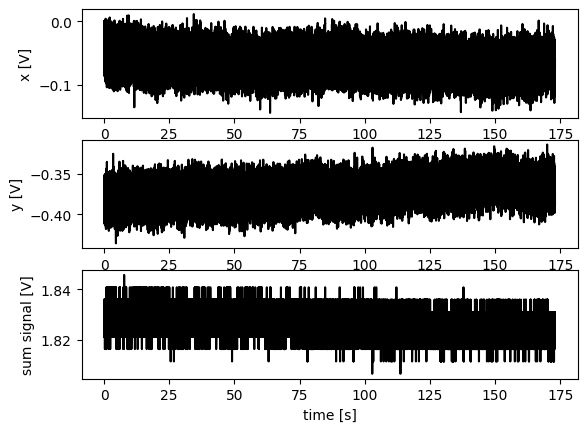

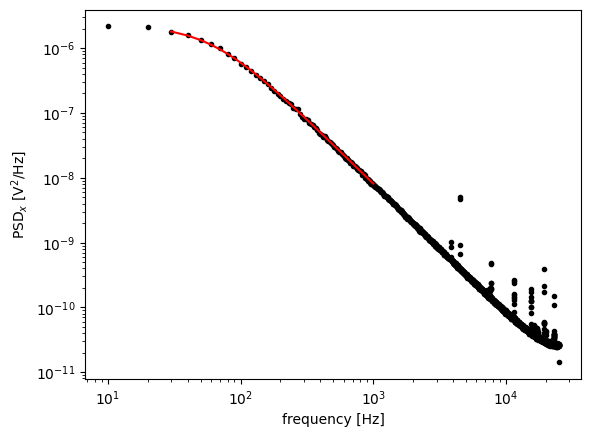

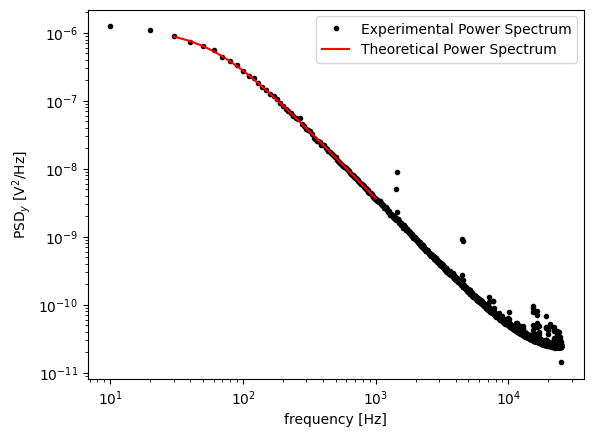

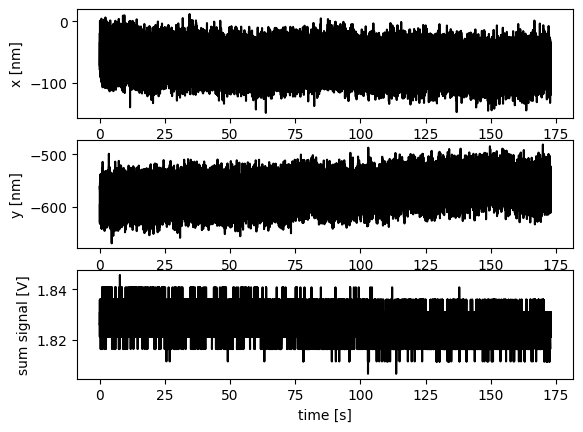

In [22]:
pathname = '/Users/coledebois/Altman lab/Altmanlab/250226/'

if 'Sx' in globals():
  del Sx
  del Sy
  del trapx
  del trapy
  del kx
  del ky


xb, yb, sumsignalb, fg, f2, powerspecx2, powerspecy2 = loaddata('Brownian/Brownian_', 9, 182, 1)
calibrate(xb, yb, sumsignalb, f2, powerspecx2, powerspecy2)

# Function generator calibration (make sure it was working that day)

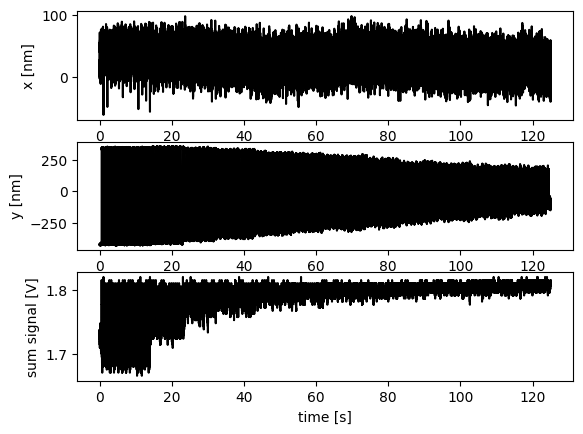

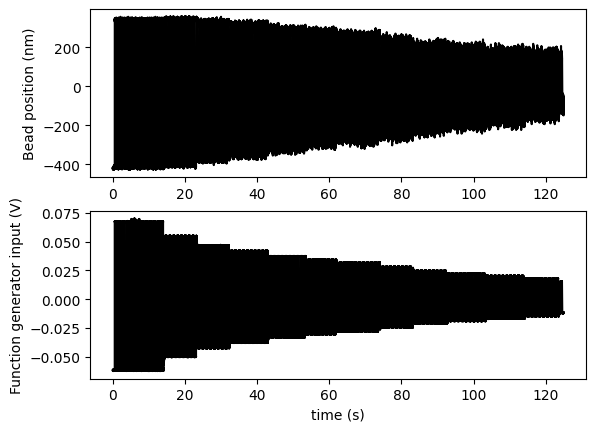

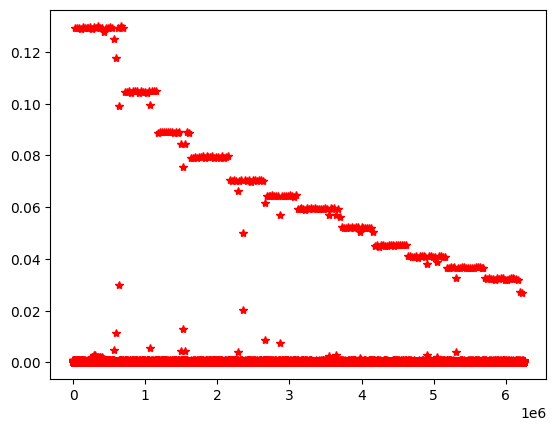

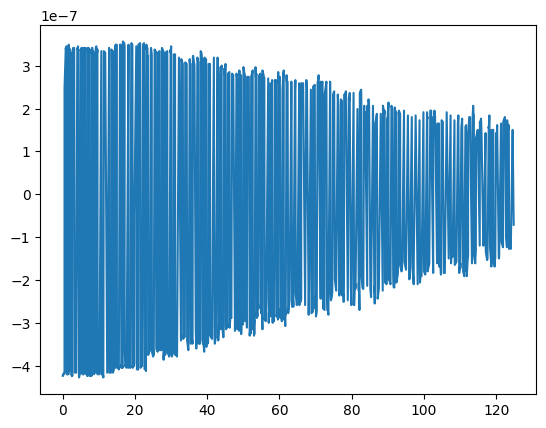

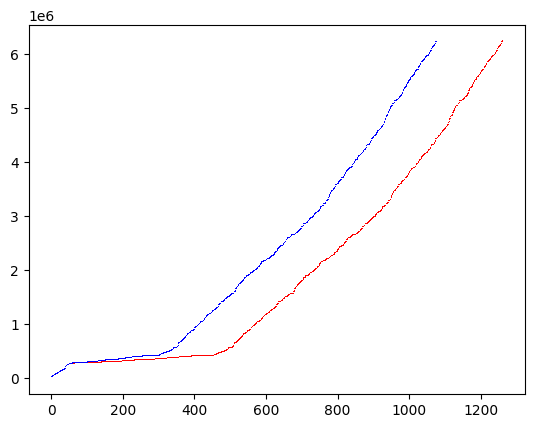

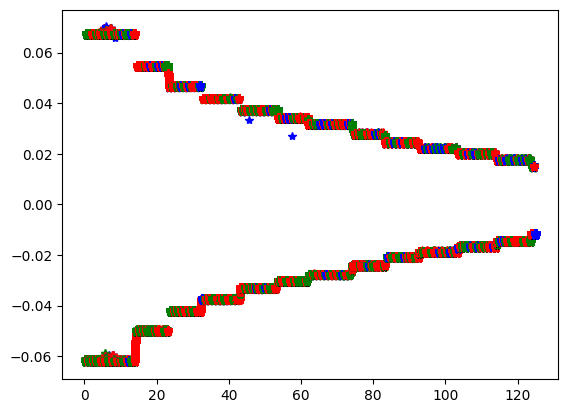

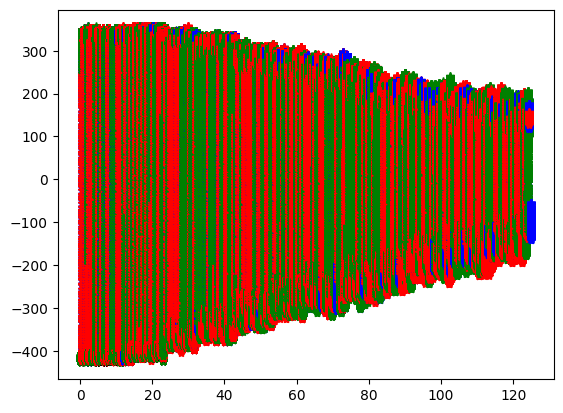

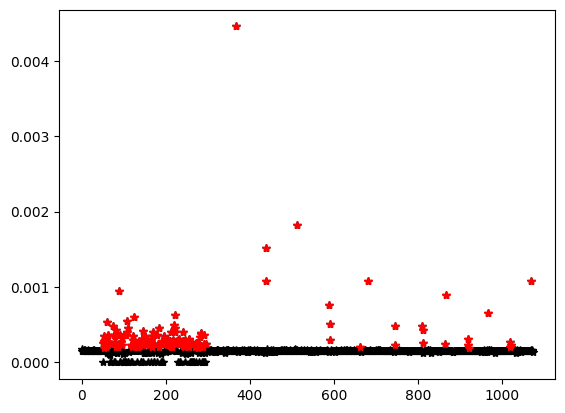

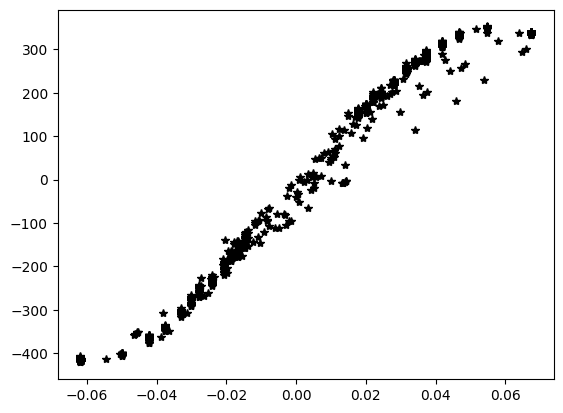

In [27]:
# pathname = '/content/drive/My Drive/Altman lab/Altman Lab Articles and Protocols/UPLOADED DATA/debois/241003/'
# Load in the data
x, y, sumsignalb, fg = loaddata('FunctionG/FunctionG_', 0, 125, 0)
times = np.arange(0, len(fg)*dt, dt)

plt.figure()
plt.subplot(2, 1, 1)
plt.plot(times, y*1e9, 'k')
plt.ylabel('Bead position (nm)')
plt.subplot(2, 1, 2)
plt.plot(times, fg, 'k')
plt.ylabel('Function generator input (V)')
plt.xlabel('time (s)')

# look for the transition points, where the function generator signla jumps
absdiff = np.append(np.abs(np.diff(fg)), 0)
#plt.figure()
#plt.plot(times, absdiff, 'k')
index = absdiff>(np.mean(absdiff)*5)
indexvalues = np.arange(0, len(index), 1)

plt.figure()
plt.plot(absdiff, 'r*')
plt.show()
plt.figure()
plt.plot(times[index], y[index])
plt.show()

# reduce the transtion points with multiple consecutive points to a single point
indexvaluesmarked = indexvalues[index]
indexvalueskeep = np.array([])
oldindex = indexvaluesmarked[0]
for i in range(1, len(indexvaluesmarked)):
  if indexvaluesmarked[i] == oldindex + 1:
    oldindex = indexvaluesmarked[i]
  else:
    indexvalueskeep = np.append(indexvalueskeep, oldindex)
    oldindex = indexvaluesmarked[i]
  
plt.plot(indexvaluesmarked, 'r,')
plt.plot(indexvalueskeep, 'b,')


# Plot of the oscillating function generator signal, blue is where the calibration will be calculated
# calculation is done between (0.85 and 0.95 of the period) following the transition
plt.figure()
stdfg = np.array([])
for i in range(len(indexvalueskeep)-1):
   rangeval = (times > (times[int(indexvalueskeep[i])])) * (times < (times[int(indexvalueskeep[i+1])]))
   if int(i/2) == int(i)/2:
     plt.plot(times[rangeval], fg[rangeval] , 'g*')
     stdfg = np.append(stdfg, np.std(fg[rangeval]))
   else:
     plt.plot(times[rangeval], fg[rangeval] , 'r*')
     stdfg = np.append(stdfg, np.std(fg[rangeval]))

   rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.85)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)])) ##!!
   plt.plot(times[rangeval],fg[rangeval], 'b*')

# Plot of the oscillating y signal, blue is where the calibration will be calculated
plt.figure()
for i in range(len(indexvalueskeep)-1):
   rangeval = (times > (times[int(indexvalueskeep[i])])) * (times < (times[int(indexvalueskeep[i+1])]))
   if int(i/2) == int(i)/2:
     plt.plot(times[rangeval], 1e9*y[rangeval] , 'g*')
   else:
     plt.plot(times[rangeval], 1e9*y[rangeval] , 'r*')

   rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.85)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
   plt.plot(times[rangeval],1e9*y[rangeval], 'b*')

# Plot to help us see what data are being thrown away because the amplitude at the fg is being varied
oscilnumber = np.arange(0, len(stdfg), 1)
plt.figure()
plt.plot(oscilnumber, stdfg, 'k*')
plt.plot(oscilnumber[stdfg>1.1*np.mean(stdfg)], stdfg[stdfg>1.1*np.mean(stdfg)], 'r*')

# This is our final calibration plot
plt.figure()
meanfgvals = np.array([])
meanyvals = np.array([])
for i in range(len(indexvalueskeep)-1):
  if stdfg[i]<1.1*np.mean(stdfg): #skip transition points that are from us changing the amplitude
    rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.75)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
    meanfg = np.mean(fg[rangeval])
    meany = np.mean(y[rangeval])
    plt.plot(meanfg, meany*1e9, 'k*')

    meanfgvals = np.append(meanfgvals, meanfg)
    meanyvals = np.append(meanyvals, meany)

  else:
    #print('skip oscillation: ', i) # these are where we were changing the amplitude in the middle of the oscillation
    pass


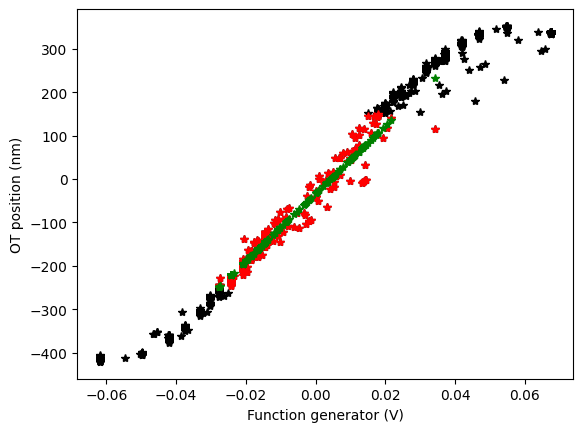

In [28]:
plt.figure()
meanfgvals = np.array([])
meanyvals = np.array([])
for i in range(len(indexvalueskeep)-1):
  if stdfg[i]<1.1*np.mean(stdfg):
    rangeval = (times > (times[int(indexvalueskeep[i])+int(fs/2*0.75)])) * (times < (times[int(indexvalueskeep[i])+int(fs/2*0.95)]))
    meanfg = np.mean(fg[rangeval])
    meany = np.mean(y[rangeval])
    plt.plot(meanfg, meany*1e9, 'k*')

    meanfgvals = np.append(meanfgvals, meanfg)
    meanyvals = np.append(meanyvals, meany)

  else:
    #print('skip oscillation: ', i) # these are where we were changing the amplitude in the middle of the oscillation
    pass

# if we only trust the detector to a few 100 nm's away from the center, we should fit from about -400 <--> 400 along the y-detection
index = (meanyvals < 150*1e-9)*(meanyvals > -250*1e-9)
plt.plot(meanfgvals[index], 1e9*meanyvals[index], 'r*')

# Fitting a line
a, b = np.polyfit(meanfgvals[index], 1e9*meanyvals[index], 1)
plt.plot(meanfgvals[index], a * meanfgvals[index] + b, 'g*')
plt.ylabel('OT position (nm)')
plt.xlabel('Function generator (V)')

def OTposconversion(fgvals, a, b):
  return a * fgvals** + b


# Here is the passive microrheology of the Brownian motion - for BEAD 3

499999
999998


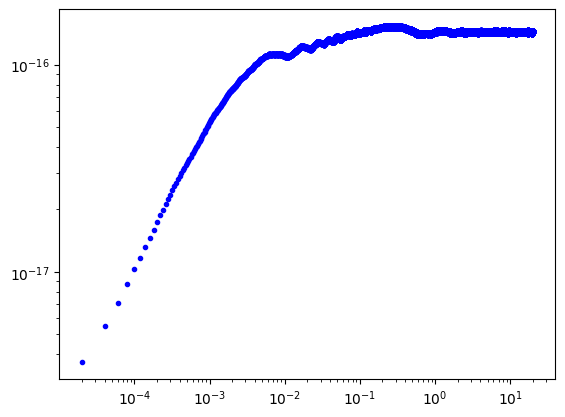

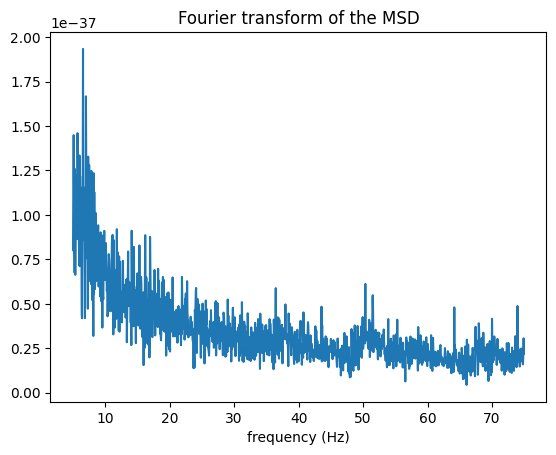

/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.10/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


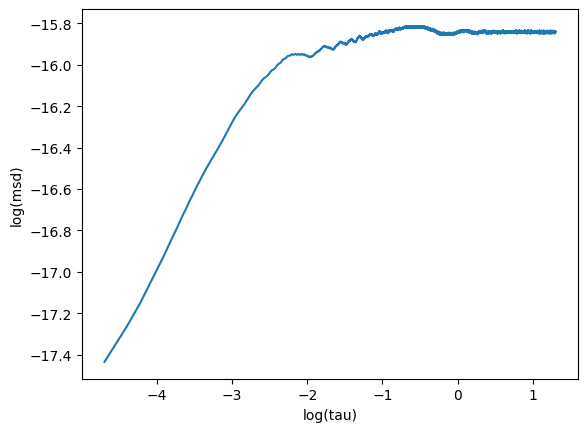

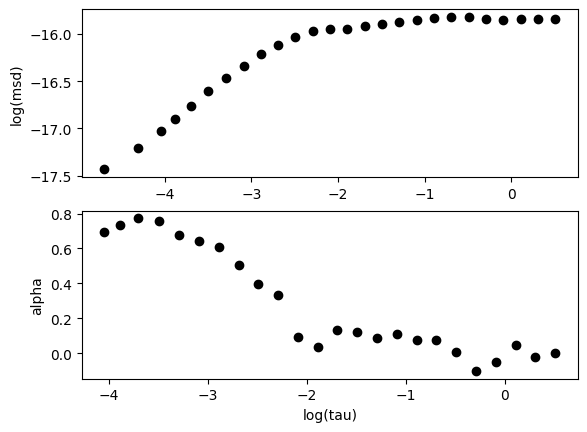

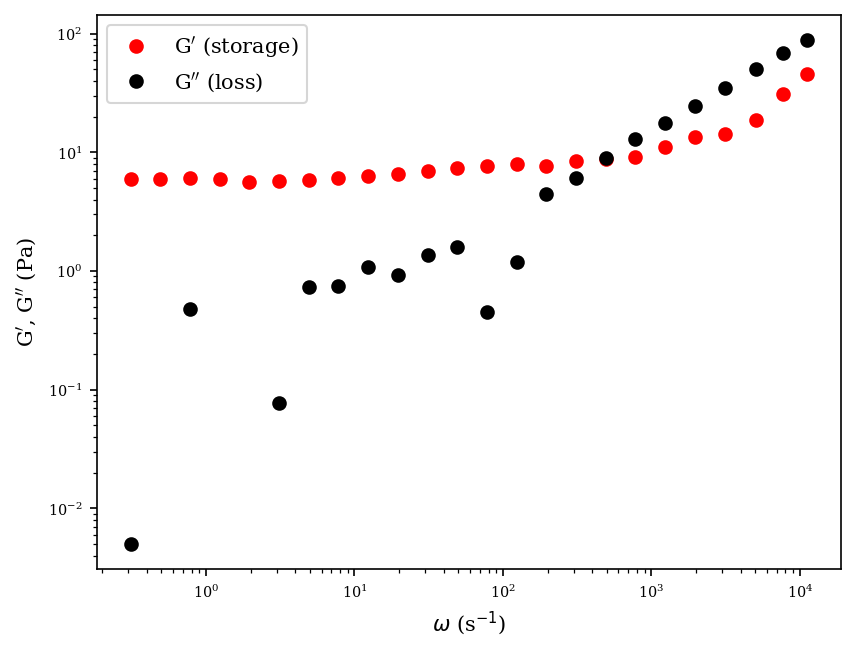

In [ ]:
from scipy import signal

pathname = '/content/drive/My Drive/Altman lab/Altman Lab Articles and Protocols/UPLOADED DATA/debois/241003/'

def calcmsd2(x, y, analysislength, msdlength):

    dt = 1/50000
    fs = 50000
  # Select data to analyze MSD and fourier transform
    xdata = x[0:int(analysislength/dt)]
    ydata = y[0:int(analysislength/dt)]


    sos = signal.butter(10, 1, 'hp', fs=50000, output='sos')
    xdata = signal.sosfilt(sos, xdata)
    ydata = signal.sosfilt(sos, ydata)


    msdvalues = msd_fft(xdata, ydata)
    tautemp = msdvalues.tau
    msdtemp = msdvalues.msd
    msdvalues.tau = tautemp[0:int(msdlength/dt)]
    msdvalues.msd = msdtemp[0:int(msdlength/dt)]

    plt.figure()
    plt.loglog(msdvalues.tau[1:int(msdlength/(dt))], msdvalues.msd[1:int(msdlength/(dt))], 'b.', label = 'Bead in the Optical Trap')
    plt.figure()
    msddata = np.array(msdvalues.msd[1:int(msdlength/dt)]) / (1e18)
    N = len(msddata)
    T = 1/fs
    yf = fft(msddata)
    xf = fftfreq(N, T)[:N//2]

    print(len(xf))
    print(len(yf))
    plt.plot(xf[100:1500], 2.0/N * np.abs(yf[100:1500]))
    plt.xlabel('frequency (Hz)')
    plt.title('Fourier transform of the MSD')
    plt.show()
    return msdvalues

msdave = np.zeros(int(0.1*fs))
x, y, sumsignal, fg= loaddataquiet('bead3p/bead3p_', 0, 120, 0) # output is in m

msdvalues = calcmsd2(x, y, 120, 20) # Analyze the first 130 s, calculating the MSD for a maximum tau fo 20 s
msdvaluesdata1 =  msdvalues
# initialize a list
alpha_list = []
omega_list = []
logtau_list = []
logmsd_list = []
tau_list = []
msd_list = []
analysislength = 20

def linear_alpha(x,m,b):
    return m*x+b
#fitting this line to the slope of the range of eleven different values of MSD data (log(tau)vs log(msd)) using an analytical method
#for i in range(6,np.int(msdlength*fs)-5): full range


N = 0.2 #iteration step

logmsd = np.log10(msdvaluesdata1.msd[:int(analysislength*fs)])
logtau = np.log10(msdvaluesdata1.tau[:int(analysislength*fs)])
msd = (msdvaluesdata1.msd[:int(analysislength*fs)])
tau = (msdvaluesdata1.tau[:int(analysislength*fs)])

plt.figure()
plt.plot(logtau, logmsd)
plt.xlabel('log(tau)')
plt.ylabel('log(msd)')
plt.show()

for i in np.arange(-5, np.log10(5)-N, N):

    index = (logtau > i) * (logtau <i+N)
    logmsdsel = (logmsd[index])
    logtausel = (logtau[index])

    msdsel = msd[index]
    tausel = tau[index]

    n = len(tausel)

    logmsd_list.append(np.mean(logmsdsel))
    logtau_list.append(np.mean(logtausel))
    msd_list.append(np.mean(msdsel))
    tau_list.append(np.mean(tausel))

    omega_list.append(1/(10**(logtau_list[-1])))

    # METHOD 2 for calculating the slope
    if len(logmsd_list)>1:
        slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])
    else:
        slope = float("NaN")

    alpha_list.append(slope)

# DAVID: This plot shows us ln(msd) vs ln(tau) on the top.  The alpha curve on the bottom should be the slope of this curve
#   You may notice that the slope looks like it was calculated really well for the first part of the curve, but as we
#   move to the right, and the slope approaches zero, our calculation of the slope is  noisy
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(logtau_list, logmsd_list, 'ko')
plt.ylabel('log(msd)')

plt.subplot(2, 1, 2)
plt.plot(logtau_list, alpha_list, 'ko')
plt.ylabel('alpha')
plt.xlabel('log(tau)')
plt.show()

logtau_list_data = logtau_list
logmsd_list_data = logmsd_list

#CONSTANTS
d = 2 # number of dimensions (x and y)
T = 293.15 # room temp --> 20 celcius = 293.15 Kelvin
K_B = 1.3806e-23 # Boltzmann Constant J/K
radius = (2.0e-6)/2  # radius of the bead, we used 2.01 um diameter beads, multiplied by 10^-6 to get in meters (m)
kBT = 4.11e-21 # room temp * Boltzmann Const.

#lists
Greals2 = [] #list for all G'
Gimags2 = [] #List for all G''
Gstar_primes2 = []
Gstar_Dprimes2 = []
Gstars2 = []
#omegafinal2 = [];
for i in range (1, len(alpha_list)):
    #ω = 1 / tau[i]
    #msd = msd[i]
    #αω = αω[i-1]
    gamma = (0.457*(1+alpha_list[i])**2) - (1.36*(1+alpha_list[i])) + 1.9 #approx value from Mason 2000 p.373 below eqn. 8
    Gstar2 = abs((2*d*K_B*T) / (6*np.pi*radius*msd_list[i]*gamma))
    Gstars2.append(Gstar2)
    Gstar_prime2 = Gstar2 * np.cos((np.pi*alpha_list[i])/2)
    Gstar_Dprime2 = Gstar2 * np.sin((np.pi*alpha_list[i])/2)
    Gstar_primes2.append(Gstar_prime2)
    Gstar_Dprimes2.append(Gstar_Dprime2)

    ktrap = (kx+ky)/2
    offset =  ktrap/(6*np.pi*(1e-6))

    # DAVID: you need to subtract k / (6*pi*a) (kept in SI units)
    Greal2 = Gstar_prime2 #- offset # G' is subtracted by stiffness of the trap because it is the real component
    Gimag2 = Gstar_Dprime2
    Greals2.append(Greal2)
    Gimags2.append(Gimag2)
    #omegafinal2.append(1/msdvaluesdata1.tau[i])

plt.rc('font', family='serif')
plt.rc('xtick', labelsize='x-small')
plt.rc('ytick', labelsize='x-small')
plt.rcParams['figure.dpi']= 150

Greals2 = np.array(Greals2)
Gimags2 = np.array(Gimags2)

plt.figure()
plt.loglog(omega_list[1:], Greals2, 'ro', label='G$^\prime$ (storage)')
plt.loglog(omega_list[1:], Gimags2, 'ko', label='G$^{\prime\prime}$ (loss)')
#plt.loglog(omega_list[1:], np.ones(len(omega_list[1:]))*((kx+ky)/2)/(6*np.pi*1e-6), 'g-')
#plt.loglog(omega_list[1:], np.ones(len(omega_list[1:]))*eta*omega_list[1:], 'g-')

#plt.loglog(omega_list[1:], offset*np.ones(len(omega_list)-1), '--')
plt.xlabel(r'$\omega$ (s$^{-1}$)')
plt.ylabel(r'G$^\prime$, G$^{\prime\prime}$ (Pa)')
plt.legend()
plt.show()

Greals2_data = Greals2
Gimags2_data = Gimags2
omega_list_data = omega_list



# Active microrheology analysis

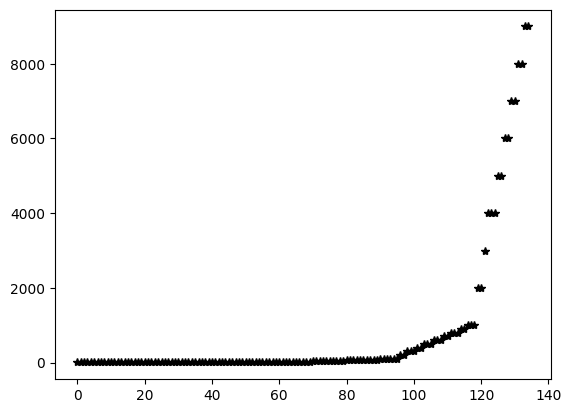

In [ ]:
# pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/241003/'

plt.figure()
frequencies = np.array([])
for i in range(0, 135):
  x, y, sumsignal, fg= loaddataquiet('bead3/bead3_', i, i+1, 0)
  t = np.arange(0, len(yb)/fs, 1/fs)
  Y = fft(fg)
  N = len(Y)
  n = np.arange(N)
  T = N/fs
  freq = n/T
  index = (freq>0.1)*(freq<20000)
  freqsec = freq[index]
  Ysec = np.abs(Y[index])
  frequencies = np.append(frequencies, freqsec[Ysec == np.max(Ysec)])
plt.plot(frequencies, 'k*')

frequenciesold = frequencies[0]

# Try fitting five periods to a sine wave
from scipy import optimize
def sinefit(t, A, C, D, omega):
    return np.abs(A) * np.sin(omega*t - C)+D
def sinefit2(freqoscil):
  def func(t,*p):
    return np.abs(p[0]) * np.sin(freqoscil*t - p[1])+p[2]
  return func

plt.show()

# Let's say we want 50 oscillations for our fitting
# time = 50/frequency = the number of data files
# but we can't do this for 1 HZ...because we only have 15 files...stick with 10 oscillations

freqlist = np.array([])
Fnot = np.array([])
ynot = np.array([])
delta = np.array([])
for i in range(0, len(frequencies)):

  if frequencies[i] < 30:
    Nfit = 10
  else:
    Nfit = 100

  if (i == 0) or (frequencies[i]-frequenciesold > 1):

    # Start by fitting the function generator to get the frequency of oscillation
    if i == 0:
      x, y, sumsignal, fg= loaddataquiet('bead3/bead3_', 0, 15, 0)
    else:
      x, y, sumsignal, fg= loaddataquiet('bead3/bead3_', i+1, i+int(100/frequencies[i])+2, 0)
    times = np.arange(0, dt*len(y), dt)
    plt.figure()
    plt.subplot(6, 1, 1)
    xdata = t[0:int(Nfit*50000/frequencies[i])]
    OTdata = a*fg[0:int(Nfit*50000/frequencies[i])]+b
    plt.plot(xdata, OTdata, 'k')
    params, params_covariance = optimize.curve_fit(sinefit, xdata, OTdata, p0=[np.std(OTdata)*np.sqrt(2), np.pi, 0, 2*np.pi*frequencies[i]])
    phase = params[1]
    #if phase < 0:
    #  phase = phase+2*np.pi
    print('FG frequency: ', params[3]/(2*np.pi))# , 'and phase', phase)
    freqlist = np.append(freqlist, params[3]/(2*np.pi))
    #fgphase = params[1]
    plt.plot(xdata, sinefit(xdata, *params), 'r-')

    # Now calculate the force exerted on the bead
    ydata = y[0:int(Nfit*50000/frequencies[i])]*1e9
    Fcurve = -(ky / 1e-12 * 1e-9) * ((ydata-np.mean(ydata)) - (OTdata-np.mean(OTdata)))  # in pN

    # Fit the ydata
    Noscil = 3
    plt.subplot(6, 1, 2)
    plt.plot(xdata, ydata, 'k')
    freqoscil = params[3]/(2*np.pi)
    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), xdata, ydata, p0=[np.std(ydata)*np.sqrt(2), 0, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.plot(xdata, sinefit(xdata, *params), 'r-')
    phase = params[1]
    print('YDATA, Fitting all oscillations - frequency: ', params[3]/(2*np.pi), 'Amplitude:', params[0], ' and phase: ', phase)
    aveydata = np.zeros(int((Noscil/freqoscil)/dt))
    count = 0
    for j in range(0, len(ydata), int((Noscil/freqoscil)/dt)):
      if len(ydata[j:j+int((Noscil/freqoscil)/dt)]) == len(aveydata):
        count = count+1
        aveydata = aveydata + ydata[j:j+int((Noscil/freqoscil)/dt)]
        plt.subplot(6, 1, 3)
        times = dt*np.arange(0, len(ydata[j:j+int((Noscil/freqoscil)/dt)]), 1)
        plt.plot(times, ydata[j:j+int((Noscil/freqoscil)/dt)], 'k-')
    aveydata = aveydata/count
    plt.plot(times, aveydata, 'r')
    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveydata, p0=[np.std(ydata)*np.sqrt(2), phase, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.plot(times, sinefit(times, *params), 'b-')
    frequenciesold = frequencies[i]
    phase = params[1]
    print('YDATA, Fitting averaged oscillations - frequency: ', params[3]/(2*np.pi), 'Amplitude: ', params[0], ' and phase: ', phase)
    yphase = phase
    ynot = np.append(ynot, params[0]*1e-9)

   # Fit the forces
    plt.subplot(6, 1, 4)
    plt.plot(xdata, Fcurve, 'k')
    freqoscil = params[3]/(2*np.pi)
    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), xdata, Fcurve, p0=[np.std(Fcurve)*np.sqrt(2), 0, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.plot(xdata, sinefit(xdata, *params), 'r-')
    print('FORCE, Fitting all oscillations - frequency: ', params[3]/(2*np.pi), 'Amplitude:', params[0], ' and phase: ', params[1])
    aveFdata = np.zeros(int((Noscil/freqoscil)/dt))
    count = 0
    for j in range(0, len(Fcurve), int((Noscil/freqoscil)/dt)):
      if len(Fcurve[j:j+int((Noscil/freqoscil)/dt)]) == len(aveFdata):
        count = count+1
        aveFdata = aveFdata + Fcurve[j:j+int((Noscil/freqoscil)/dt)]
        plt.subplot(6, 1, 5)
        times = dt*np.arange(0, len(Fcurve[j:j+int((Noscil/freqoscil)/dt)]), 1)
        plt.plot(times, Fcurve[j:j+int((Noscil/freqoscil)/dt)], 'k-')
    aveFdata = aveFdata/count
    plt.plot(times, aveFdata, 'r')
    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveFdata, p0=[np.std(ydata)*np.sqrt(2), 0, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.plot(times, sinefit(times, *params), 'b-')
    frequenciesold = frequencies[i]
    print('FORCE, Fitting averaged oscillations - frequency: ', params[3]/(2*np.pi), 'Amplitude: ', params[0], ' and phase: ', params[1])
    plt.subplot(6, 1, 6)
    plt.plot(t[0:int(Nfit*50000/frequencies[i])], (ydata-np.mean(ydata)) - (OTdata-np.mean(OTdata)))
    plt.ylabel('displacement from trap center')

    deltatemp = yphase-params[1]
    if deltatemp<0:
      deltatemp = deltatemp+2*np.pi
    delta = np.append(delta, deltatemp)

    Fnot = np.append(Fnot, params[0]*1e-12)

    plt.show()

plt.figure()
plt.subplot(3, 1, 1)
plt.semilogx(freqlist, np.abs(Fnot), 'k*')
plt.subplot(3, 1, 2)
plt.semilogx(freqlist, np.abs(ynot), 'k*')
plt.subplot(3, 1, 3)
plt.semilogx(freqlist, delta, 'k*')

plt.figure()
plt.loglog(freqlist, np.abs(Fnot/ynot)*np.cos(delta), 'k*')
plt.loglog(freqlist, np.abs(Fnot/ynot)*np.sin(delta), 'r*')

Gprimebig = np.abs(Fnot/ynot)*np.cos(delta)
Gprimeprimebig = np.abs(Fnot/ynot)*np.sin(delta)
freqlistbig = freqlist

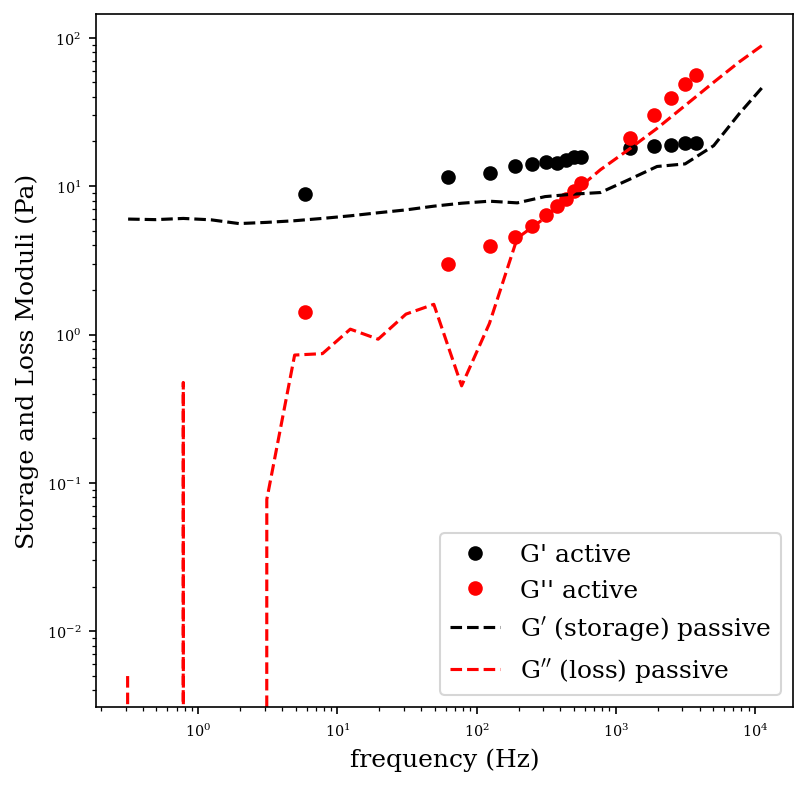

In [ ]:
Gprime = np.abs(Fnot/(6*np.pi*(1e-6)*ynot))*np.cos(delta)
Gprimeprime = np.abs(Fnot/(6*np.pi*(1e-6)*ynot))*np.sin(delta)

index = (Gprime>0.1)*(freqlist<610)
plt.figure(figsize = (6, 6))
plt.loglog(2*np.pi*freqlist[index], Gprime[index], 'ko', label = 'G\' active')
plt.loglog(2*np.pi*freqlist[index], Gprimeprime[index], 'ro', label = 'G\'\' active')

plt.loglog(omega_list[1:], Greals2, 'k--', label='G$^\prime$ (storage) passive')
plt.loglog(omega_list[1:], Gimags2, 'r--', label='G$^{\prime\prime}$ (loss) passive')


plt.xlabel('frequency (Hz)', fontsize = 12)
plt.ylabel('Storage and Loss Moduli (Pa)', fontsize = 12)
plt.legend(fontsize = 12)


# Here is the passive microrheology of the Brownian motion - for BEAD 4

499999
999998


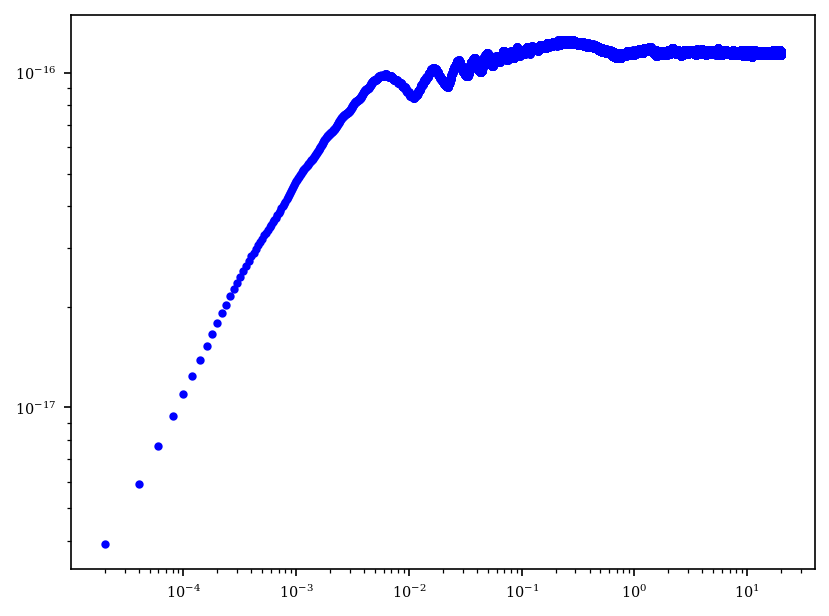

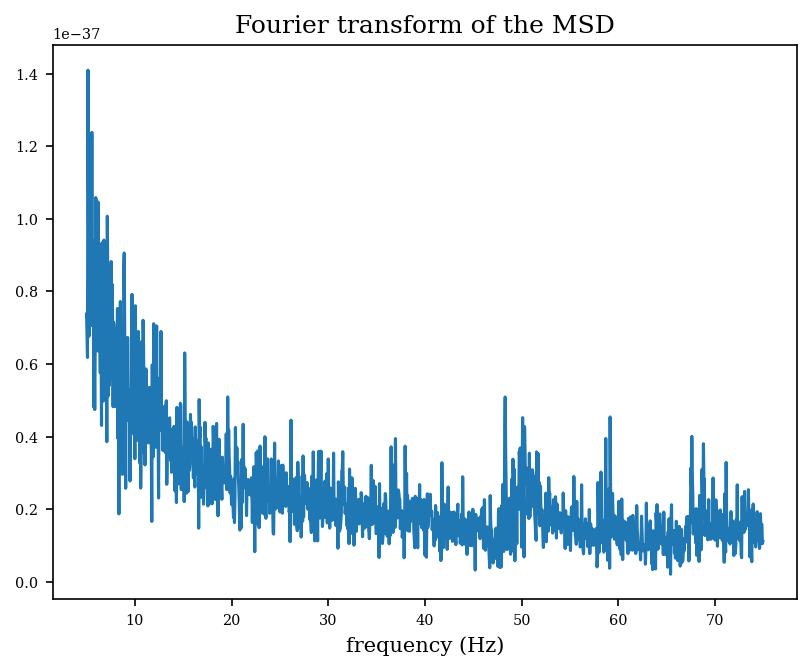

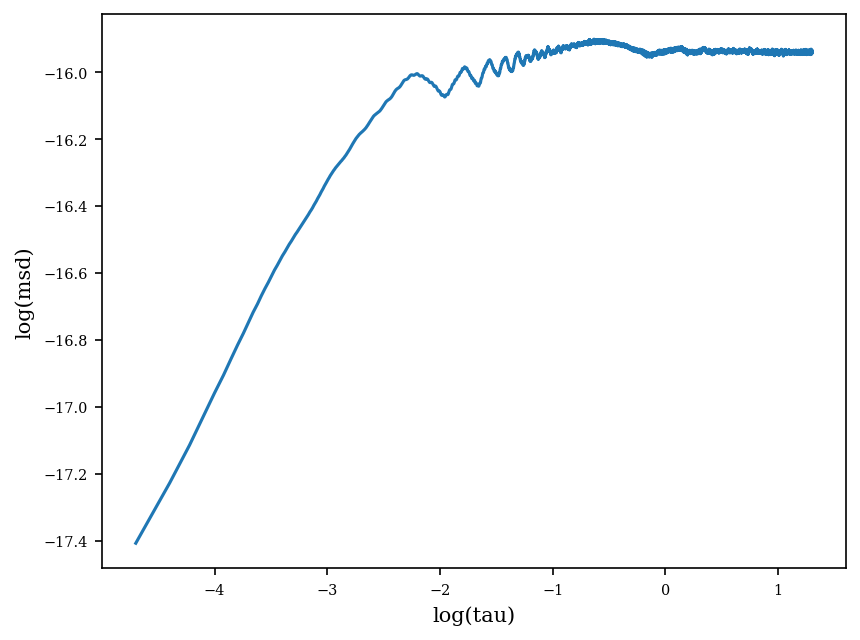

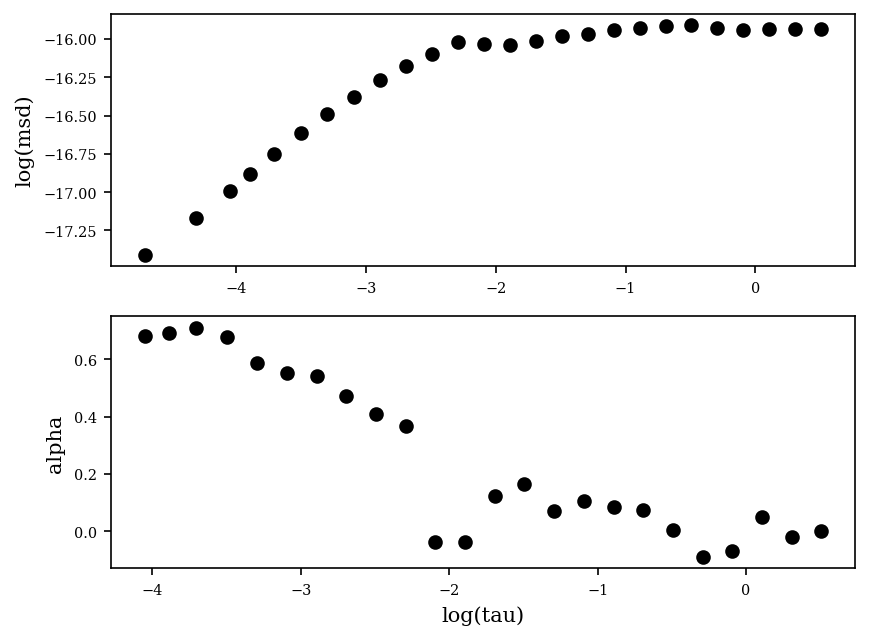

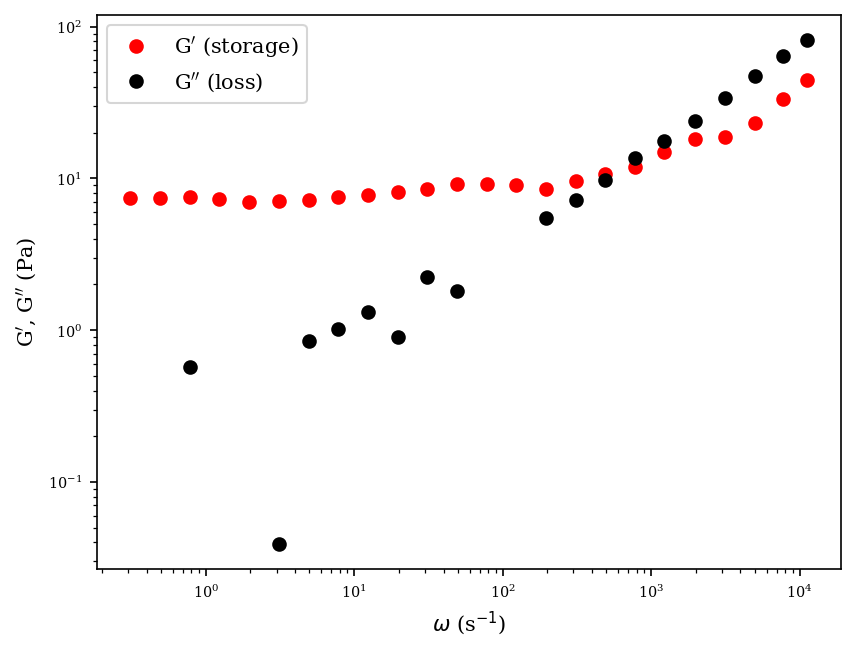

In [ ]:
from scipy import signal

pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/241003/'

def calcmsd2(x, y, analysislength, msdlength):

    dt = 1/50000
    fs = 50000
  # Select data to analyze MSD and fourier transform
    xdata = x[0:int(analysislength/dt)]
    ydata = y[0:int(analysislength/dt)]


    sos = signal.butter(10, 1, 'hp', fs=50000, output='sos')
    xdata = signal.sosfilt(sos, xdata)
    ydata = signal.sosfilt(sos, ydata)


    msdvalues = msd_fft(xdata, ydata)
    tautemp = msdvalues.tau
    msdtemp = msdvalues.msd
    msdvalues.tau = tautemp[0:int(msdlength/dt)]
    msdvalues.msd = msdtemp[0:int(msdlength/dt)]

    plt.figure()
    plt.loglog(msdvalues.tau[1:int(msdlength/(dt))], msdvalues.msd[1:int(msdlength/(dt))], 'b.', label = 'Bead in the Optical Trap')
    plt.figure()
    msddata = np.array(msdvalues.msd[1:int(msdlength/dt)]) / (1e18)
    N = len(msddata)
    T = 1/fs
    yf = fft(msddata)
    xf = fftfreq(N, T)[:N//2]

    print(len(xf))
    print(len(yf))
    plt.plot(xf[100:1500], 2.0/N * np.abs(yf[100:1500]))
    plt.xlabel('frequency (Hz)')
    plt.title('Fourier transform of the MSD')
    plt.show()
    return msdvalues

msdave = np.zeros(int(0.1*fs))
x, y, sumsignal, fg= loaddataquiet('bead4p/bead4p_', 0, 120, 0) # output is in m

msdvalues = calcmsd2(x, y, 120, 20) # Analyze the first 130 s, calculating the MSD for a maximum tau fo 20 s
msdvaluesdata1 =  msdvalues
# initialize a list
alpha_list = []
omega_list = []
logtau_list = []
logmsd_list = []
tau_list = []
msd_list = []
analysislength = 20

def linear_alpha(x,m,b):
    return m*x+b
#fitting this line to the slope of the range of eleven different values of MSD data (log(tau)vs log(msd)) using an analytical method
#for i in range(6,np.int(msdlength*fs)-5): full range


N = 0.2 #iteration step

logmsd = np.log10(msdvaluesdata1.msd[:int(analysislength*fs)])
logtau = np.log10(msdvaluesdata1.tau[:int(analysislength*fs)])
msd = (msdvaluesdata1.msd[:int(analysislength*fs)])
tau = (msdvaluesdata1.tau[:int(analysislength*fs)])

plt.figure()
plt.plot(logtau, logmsd)
plt.xlabel('log(tau)')
plt.ylabel('log(msd)')
plt.show()

for i in np.arange(-5, np.log10(5)-N, N):

    index = (logtau > i) * (logtau <i+N)
    logmsdsel = (logmsd[index])
    logtausel = (logtau[index])

    msdsel = msd[index]
    tausel = tau[index]

    n = len(tausel)

    logmsd_list.append(np.mean(logmsdsel))
    logtau_list.append(np.mean(logtausel))
    msd_list.append(np.mean(msdsel))
    tau_list.append(np.mean(tausel))

    omega_list.append(1/(10**(logtau_list[-1])))

    # METHOD 2 for calculating the slope
    if len(logmsd_list)>1:
        slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])
    else:
        slope = float("NaN")

    alpha_list.append(slope)

# DAVID: This plot shows us ln(msd) vs ln(tau) on the top.  The alpha curve on the bottom should be the slope of this curve
#   You may notice that the slope looks like it was calculated really well for the first part of the curve, but as we
#   move to the right, and the slope approaches zero, our calculation of the slope is  noisy
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(logtau_list, logmsd_list, 'ko')
plt.ylabel('log(msd)')

plt.subplot(2, 1, 2)
plt.plot(logtau_list, alpha_list, 'ko')
plt.ylabel('alpha')
plt.xlabel('log(tau)')
plt.show()

logtau_list_data = logtau_list
logmsd_list_data = logmsd_list

#CONSTANTS
d = 2 # number of dimensions (x and y)
T = 293.15 # room temp --> 20 celcius = 293.15 Kelvin
K_B = 1.3806e-23 # Boltzmann Constant J/K
radius = (2.0e-6)/2  # radius of the bead, we used 2.01 um diameter beads, multiplied by 10^-6 to get in meters (m)
kBT = 4.11e-21 # room temp * Boltzmann Const.

#lists
Greals2 = [] #list for all G'
Gimags2 = [] #List for all G''
Gstar_primes2 = []
Gstar_Dprimes2 = []
Gstars2 = []
#omegafinal2 = [];
for i in range (1, len(alpha_list)):
    #ω = 1 / tau[i]
    #msd = msd[i]
    #αω = αω[i-1]
    gamma = (0.457*(1+alpha_list[i])**2) - (1.36*(1+alpha_list[i])) + 1.9 #approx value from Mason 2000 p.373 below eqn. 8
    Gstar2 = abs((2*d*K_B*T) / (6*np.pi*radius*msd_list[i]*gamma))
    Gstars2.append(Gstar2)
    Gstar_prime2 = Gstar2 * np.cos((np.pi*alpha_list[i])/2)
    Gstar_Dprime2 = Gstar2 * np.sin((np.pi*alpha_list[i])/2)
    Gstar_primes2.append(Gstar_prime2)
    Gstar_Dprimes2.append(Gstar_Dprime2)

    ktrap = (kx+ky)/2
    offset =  ktrap/(6*np.pi*(1e-6))

    # DAVID: you need to subtract k / (6*pi*a) (kept in SI units)
    Greal2 = Gstar_prime2 #- offset # G' is subtracted by stiffness of the trap because it is the real component
    Gimag2 = Gstar_Dprime2
    Greals2.append(Greal2)
    Gimags2.append(Gimag2)
    #omegafinal2.append(1/msdvaluesdata1.tau[i])

plt.rc('font', family='serif')
plt.rc('xtick', labelsize='x-small')
plt.rc('ytick', labelsize='x-small')
plt.rcParams['figure.dpi']= 150

Greals2 = np.array(Greals2)
Gimags2 = np.array(Gimags2)

plt.figure()
plt.loglog(omega_list[1:], Greals2, 'ro', label='G$^\prime$ (storage)')
plt.loglog(omega_list[1:], Gimags2, 'ko', label='G$^{\prime\prime}$ (loss)')
#plt.loglog(omega_list[1:], np.ones(len(omega_list[1:]))*((kx+ky)/2)/(6*np.pi*1e-6), 'g-')
#plt.loglog(omega_list[1:], np.ones(len(omega_list[1:]))*eta*omega_list[1:], 'g-')

#plt.loglog(omega_list[1:], offset*np.ones(len(omega_list)-1), '--')
plt.xlabel(r'$\omega$ (s$^{-1}$)')
plt.ylabel(r'G$^\prime$, G$^{\prime\prime}$ (Pa)')
plt.legend()
plt.show()

Greals2_data = Greals2
Gimags2_data = Gimags2
omega_list_data = omega_list



#Active microrheology code

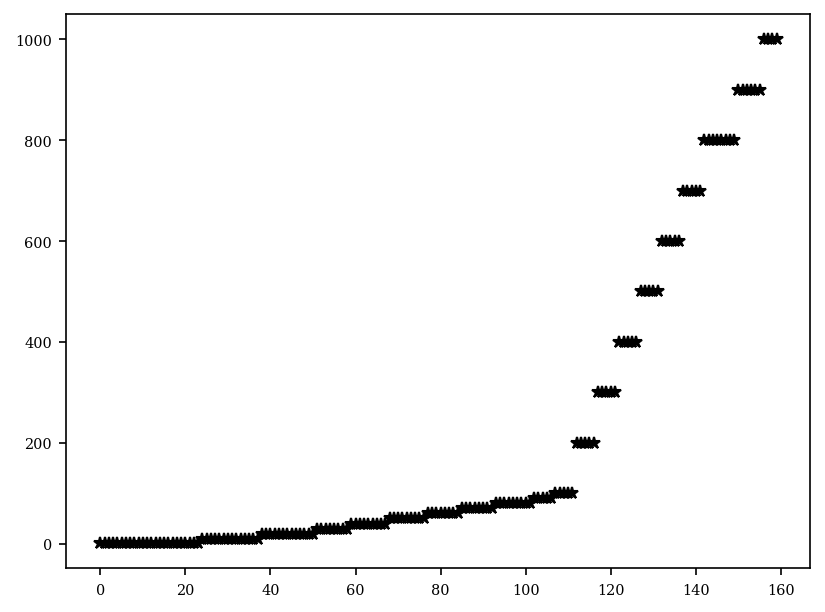

FG frequency:  0.9313165125807009
YDATA, Fitting all oscillations - frequency:  0.9313165125807009 Amplitude: 73.2287028887062  and phase:  2.7654013914094784
YDATA, Fitting averaged oscillations - frequency:  0.9313165125807009 Amplitude:  73.3018265975704  and phase:  2.7648456854181345
FORCE, Fitting all oscillations - frequency:  0.9313165125807009 Amplitude: 9.468822012783622  and phase:  2.624818473992671
FORCE, Fitting averaged oscillations - frequency:  0.9313165125807009 Amplitude:  -9.467096959195148  and phase:  2.624925735219141


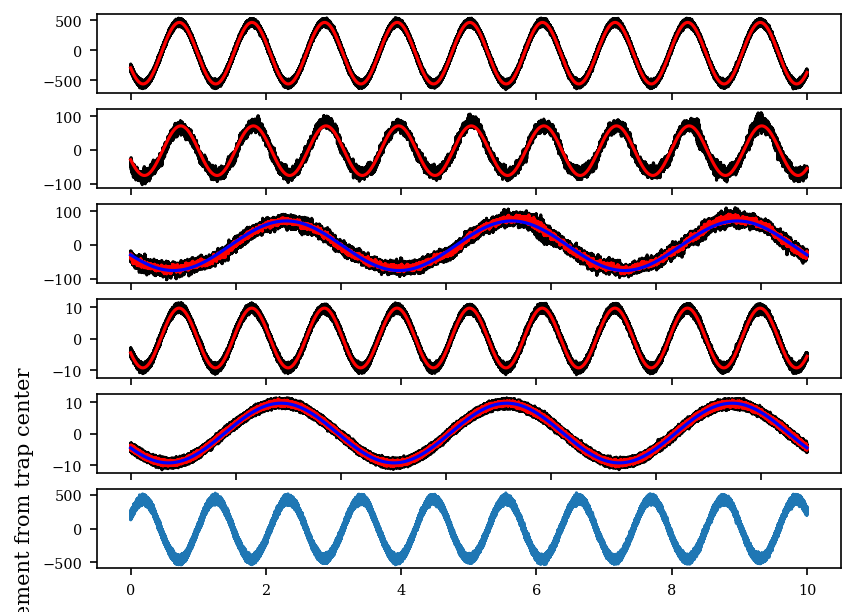

FG frequency:  9.871809778408034
YDATA, Fitting all oscillations - frequency:  9.871809778408034 Amplitude: 59.27193870165534  and phase:  0.6854168239938777
YDATA, Fitting averaged oscillations - frequency:  9.871809778408034 Amplitude:  59.1565799780139  and phase:  0.6907581327549178
FORCE, Fitting all oscillations - frequency:  9.871809778408034 Amplitude: 9.782495514953606  and phase:  0.46766431510870005
FORCE, Fitting averaged oscillations - frequency:  9.871809778408034 Amplitude:  9.784546207683752  and phase:  0.46802397305042354


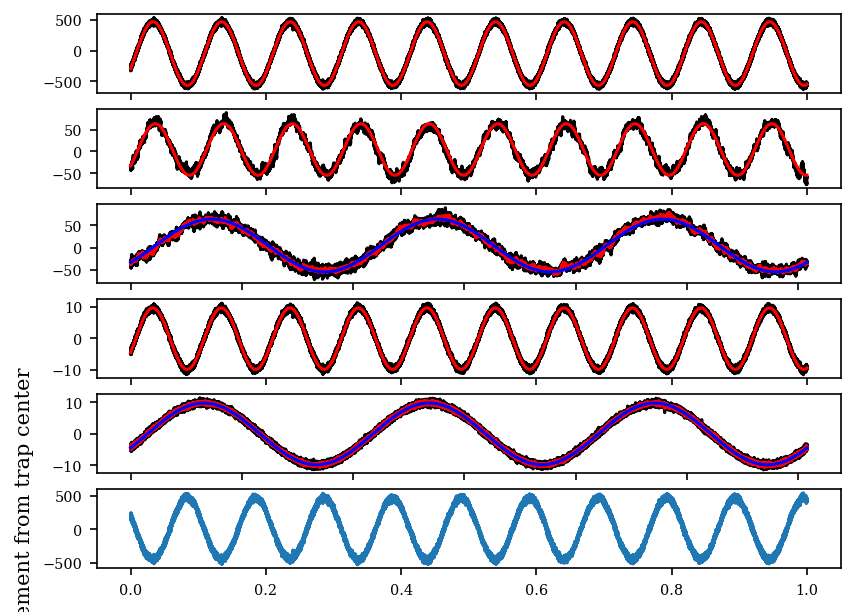

FG frequency:  19.93013789359851
YDATA, Fitting all oscillations - frequency:  19.93013789359851 Amplitude: 51.79087010024431  and phase:  5.635707500225396
YDATA, Fitting averaged oscillations - frequency:  19.93013789359851 Amplitude:  51.6631055845121  and phase:  5.632090781017406
FORCE, Fitting all oscillations - frequency:  19.93013789359851 Amplitude: 9.944492600705473  and phase:  -0.9074816177804396
FORCE, Fitting averaged oscillations - frequency:  19.93013789359851 Amplitude:  9.946218670429442  and phase:  -0.9060624189919876


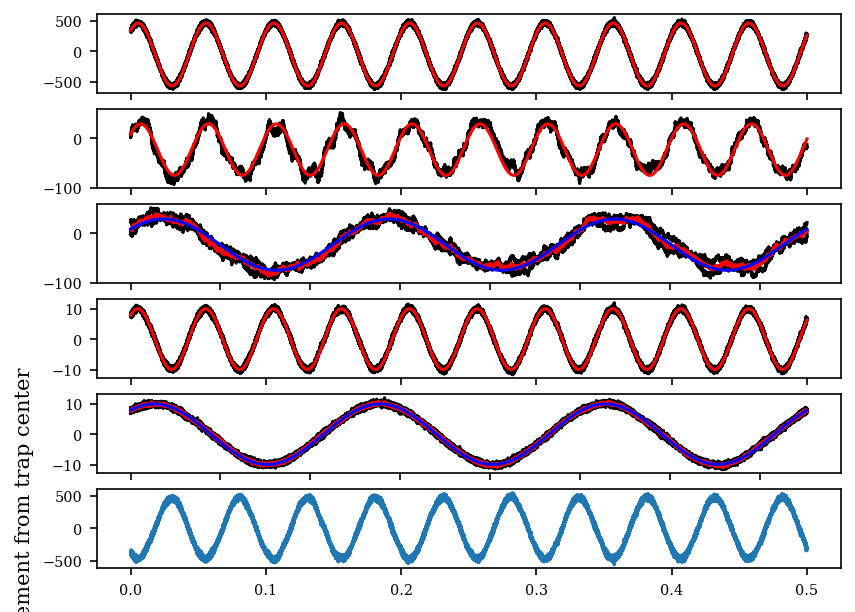

FG frequency:  29.98837842596156
YDATA, Fitting all oscillations - frequency:  29.98837842596156 Amplitude: 48.296891899603736  and phase:  3.9256932092174224
YDATA, Fitting averaged oscillations - frequency:  29.98837842596156 Amplitude:  48.26836726632643  and phase:  3.983394239939245
FORCE, Fitting all oscillations - frequency:  29.98837842596156 Amplitude: 10.040136916567064  and phase:  -2.6929343137035007
FORCE, Fitting averaged oscillations - frequency:  29.98837842596156 Amplitude:  -10.034780336571878  and phase:  -2.6365144041544437


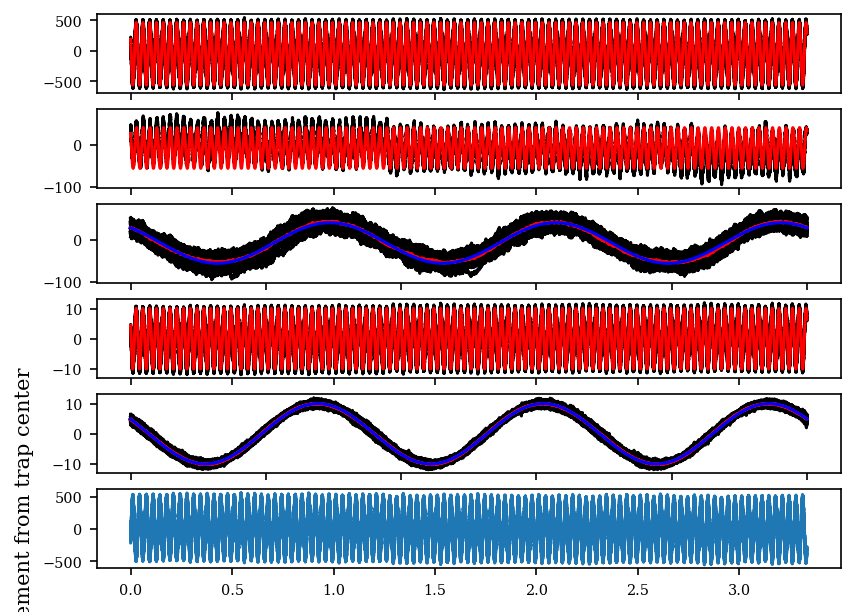

FG frequency:  39.86034069969615
YDATA, Fitting all oscillations - frequency:  39.86034069969615 Amplitude: 45.37848539425524  and phase:  3.3180735238533594
YDATA, Fitting averaged oscillations - frequency:  39.86034069969615 Amplitude:  45.425939320576745  and phase:  3.3296879318808026
FORCE, Fitting all oscillations - frequency:  39.86034069969615 Amplitude: 10.112986489427374  and phase:  2.9454334865950433
FORCE, Fitting averaged oscillations - frequency:  39.86034069969615 Amplitude:  -10.112701306827892  and phase:  2.956491663678181


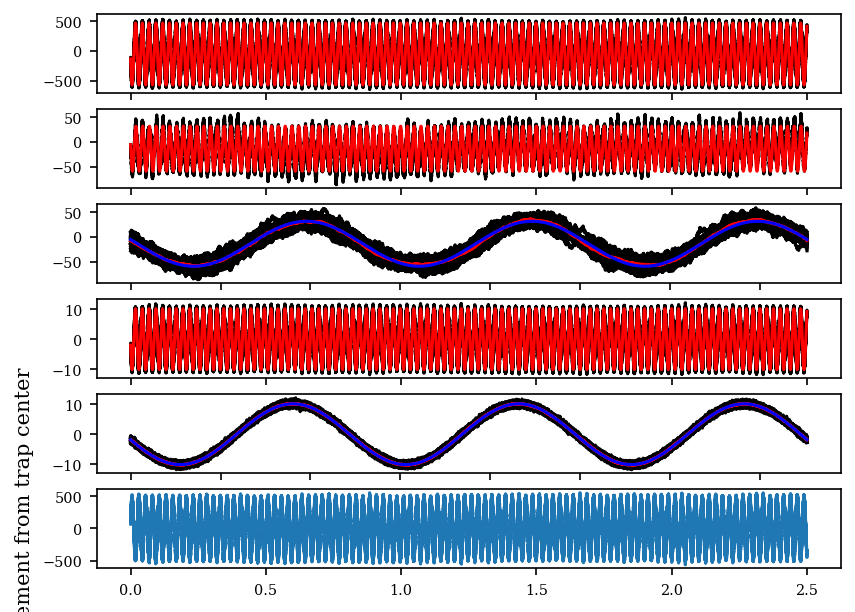

FG frequency:  49.91857346636051
YDATA, Fitting all oscillations - frequency:  49.91857346636051 Amplitude: 44.091699329458564  and phase:  4.114081861401681
YDATA, Fitting averaged oscillations - frequency:  49.91857346636051 Amplitude:  44.04565242116539  and phase:  4.2054409538801165
FORCE, Fitting all oscillations - frequency:  49.91857346636051 Amplitude: 10.162062799669433  and phase:  -2.6143228618381746
FORCE, Fitting averaged oscillations - frequency:  49.91857346636051 Amplitude:  10.14882532824846  and phase:  -2.5247367471943583


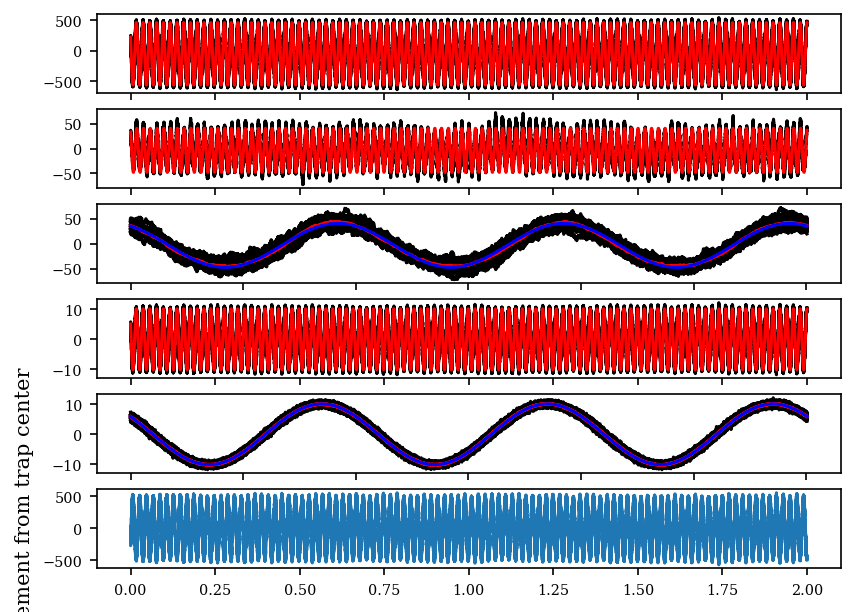

FG frequency:  59.976853871126515
YDATA, Fitting all oscillations - frequency:  59.976853871126515 Amplitude: -41.053488076914505  and phase:  4.875370291788501
YDATA, Fitting averaged oscillations - frequency:  59.976853871126515 Amplitude:  40.88605227373955  and phase:  4.990163634888616
FORCE, Fitting all oscillations - frequency:  59.976853871126515 Amplitude: -10.118697953608319  and phase:  -1.86594879182449
FORCE, Fitting averaged oscillations - frequency:  59.976853871126515 Amplitude:  -10.095188141851734  and phase:  -1.7494429534654214


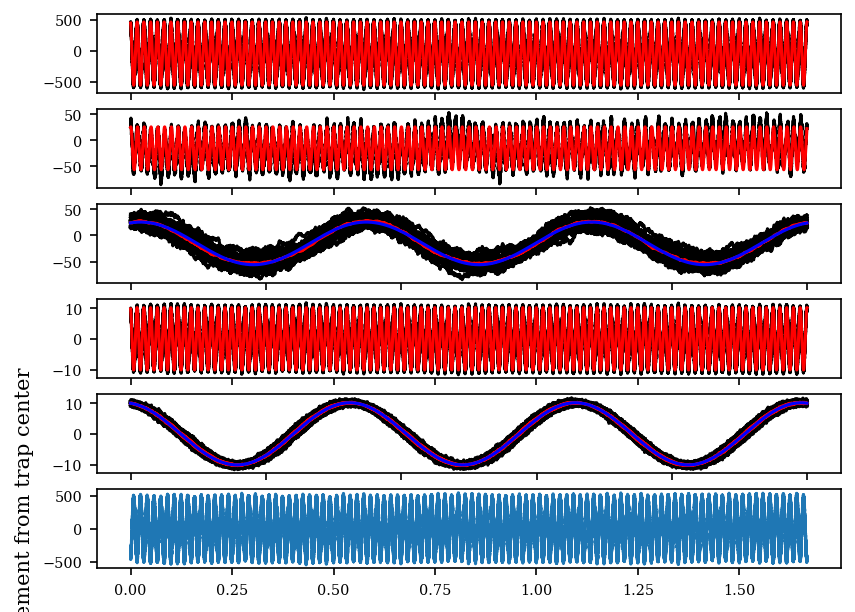

FG frequency:  69.84881295169374
YDATA, Fitting all oscillations - frequency:  69.84881295169374 Amplitude: 38.52120912306373  and phase:  3.0955637389780573
YDATA, Fitting averaged oscillations - frequency:  69.84881295169374 Amplitude:  38.48137023742197  and phase:  3.162930149610585
FORCE, Fitting all oscillations - frequency:  69.84881295169374 Amplitude: 10.289354742902306  and phase:  2.607820029274633
FORCE, Fitting averaged oscillations - frequency:  69.84881295169374 Amplitude:  -10.278981289624564  and phase:  2.677576796734892


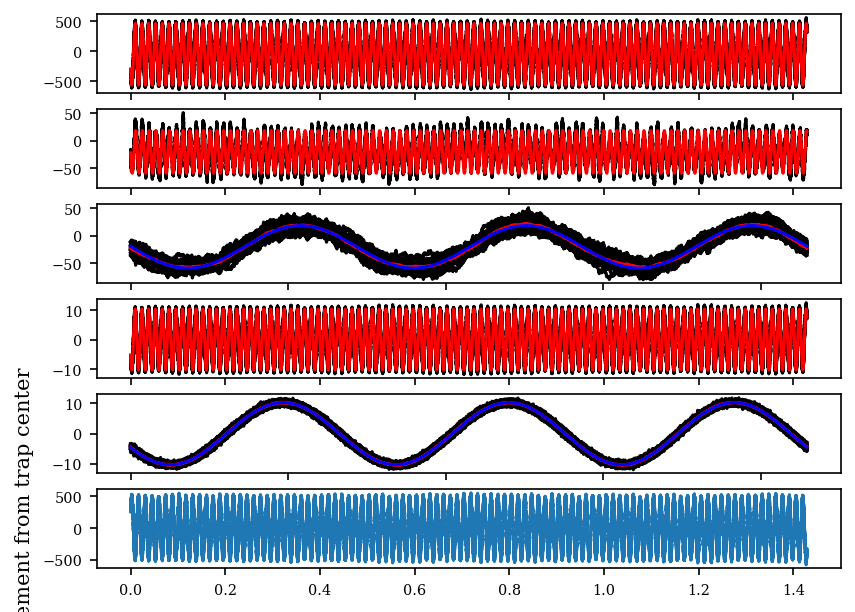

FG frequency:  79.90703474001232
YDATA, Fitting all oscillations - frequency:  79.90703474001232 Amplitude: 35.28121189926885  and phase:  1.7012616009641748
YDATA, Fitting averaged oscillations - frequency:  79.90703474001232 Amplitude:  35.31629121505746  and phase:  1.7326056514847552
FORCE, Fitting all oscillations - frequency:  79.90703474001232 Amplitude: 10.3502835306678  and phase:  1.214779905254221
FORCE, Fitting averaged oscillations - frequency:  79.90703474001232 Amplitude:  10.3482727851816  and phase:  1.2438273313044432


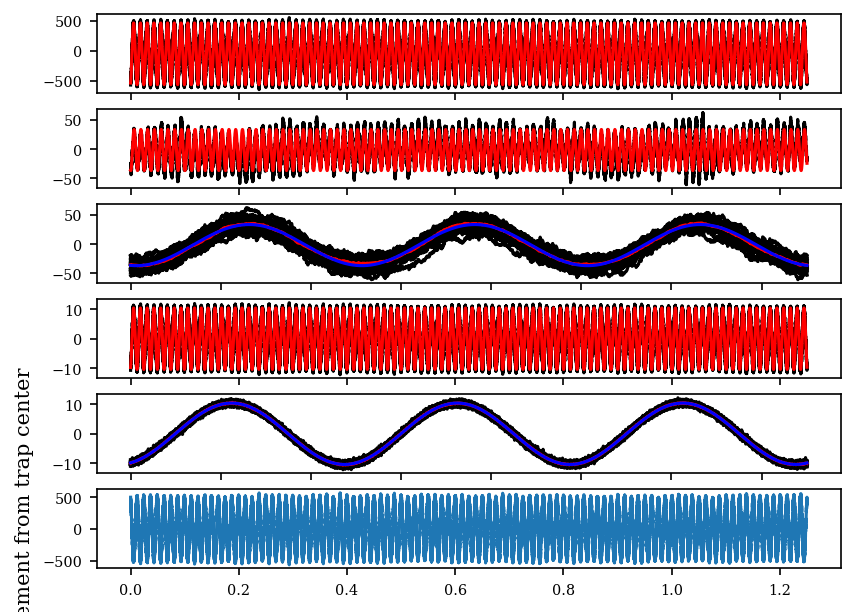

FG frequency:  89.96509968244244
YDATA, Fitting all oscillations - frequency:  89.96509968244244 Amplitude: 33.649062311356886  and phase:  3.1814735793726734
YDATA, Fitting averaged oscillations - frequency:  89.96509968244244 Amplitude:  33.65959090147171  and phase:  3.2380447571407993
FORCE, Fitting all oscillations - frequency:  89.96509968244244 Amplitude: 10.395765408676136  and phase:  2.653042744352253
FORCE, Fitting averaged oscillations - frequency:  89.96509968244244 Amplitude:  -10.38858177916313  and phase:  2.7097289478650044


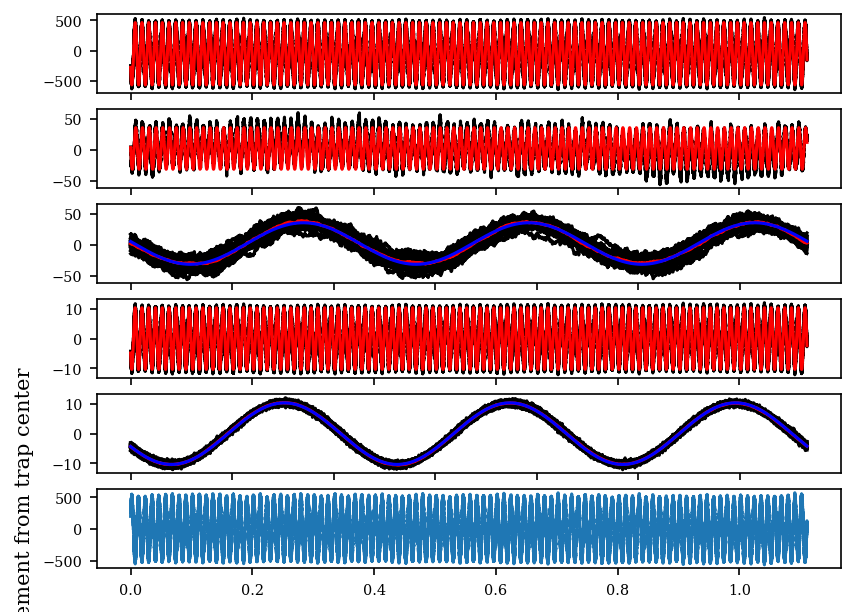

FG frequency:  99.8371164070225
YDATA, Fitting all oscillations - frequency:  99.8371164070225 Amplitude: 33.683512994758516  and phase:  4.534086696919105
YDATA, Fitting averaged oscillations - frequency:  99.8371164070225 Amplitude:  33.66545064926837  and phase:  4.623469823942449
FORCE, Fitting all oscillations - frequency:  99.8371164070225 Amplitude: 10.408220400830162  and phase:  -2.313485130679081
FORCE, Fitting averaged oscillations - frequency:  99.8371164070225 Amplitude:  10.39228666769862  and phase:  -2.2236875251093884


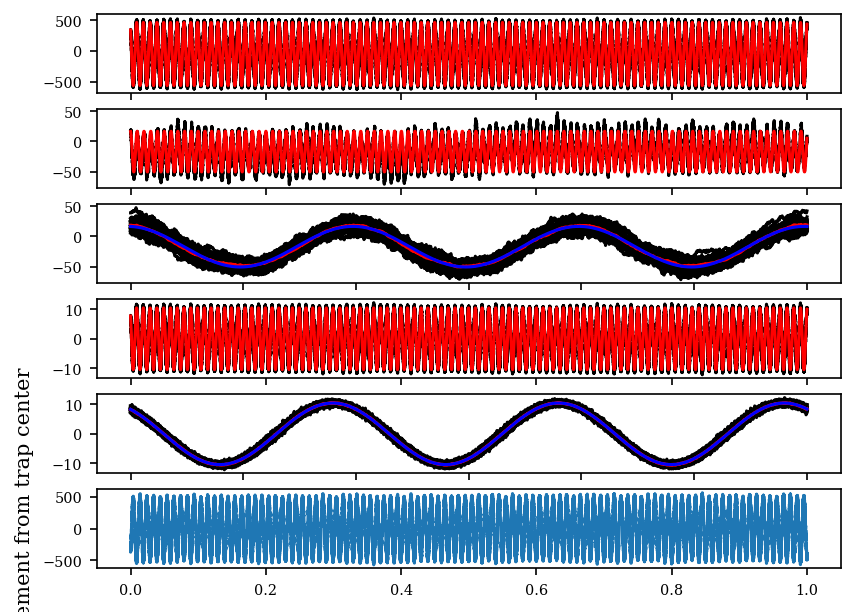

FG frequency:  199.85997434294492
YDATA, Fitting all oscillations - frequency:  199.85997434294492 Amplitude: 2.1153712464667598e-07  and phase:  2.502634015395148
YDATA, Fitting averaged oscillations - frequency:  199.85997434294492 Amplitude:  -26.07491050962421  and phase:  0.26369028727914723
FORCE, Fitting all oscillations - frequency:  199.85997434294492 Amplitude: 10.613323672977243  and phase:  -0.7062664773615556
FORCE, Fitting averaged oscillations - frequency:  199.85997434294492 Amplitude:  10.529215539509373  and phase:  -0.4951914941021396


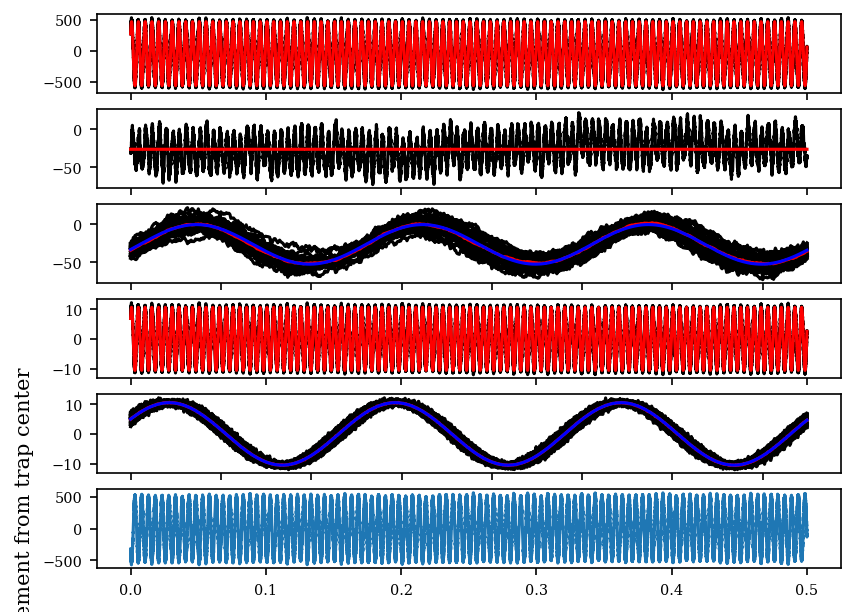

FG frequency:  299.88403555178536
YDATA, Fitting all oscillations - frequency:  299.88403555178536 Amplitude: -22.38620987212977  and phase:  4.763522404873152
YDATA, Fitting averaged oscillations - frequency:  299.88403555178536 Amplitude:  22.388381720806166  and phase:  4.878863220864766
FORCE, Fitting all oscillations - frequency:  299.88403555178536 Amplitude: 10.732781696093316  and phase:  -2.472070964617683
FORCE, Fitting averaged oscillations - frequency:  299.88403555178536 Amplitude:  10.705105198421544  and phase:  -2.3555014266572196


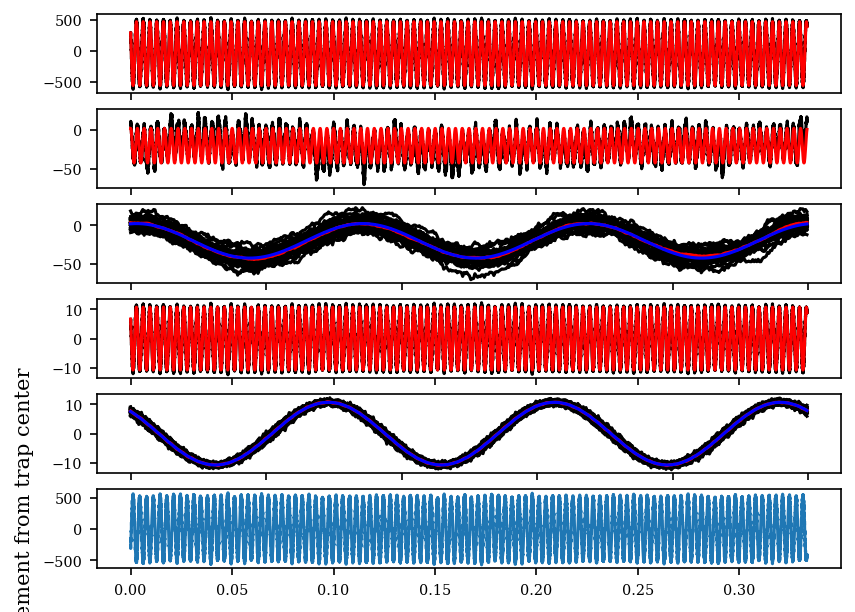

FG frequency:  399.9062354627711
YDATA, Fitting all oscillations - frequency:  399.9062354627711 Amplitude: 18.539666658184828  and phase:  4.611969401788491
YDATA, Fitting averaged oscillations - frequency:  399.9062354627711 Amplitude:  18.523868014673234  and phase:  4.683103167681794
FORCE, Fitting all oscillations - frequency:  399.9062354627711 Amplitude: 10.819706248645467  and phase:  -2.7295993910628096
FORCE, Fitting averaged oscillations - frequency:  399.9062354627711 Amplitude:  -10.810190659145508  and phase:  -2.658866275125463


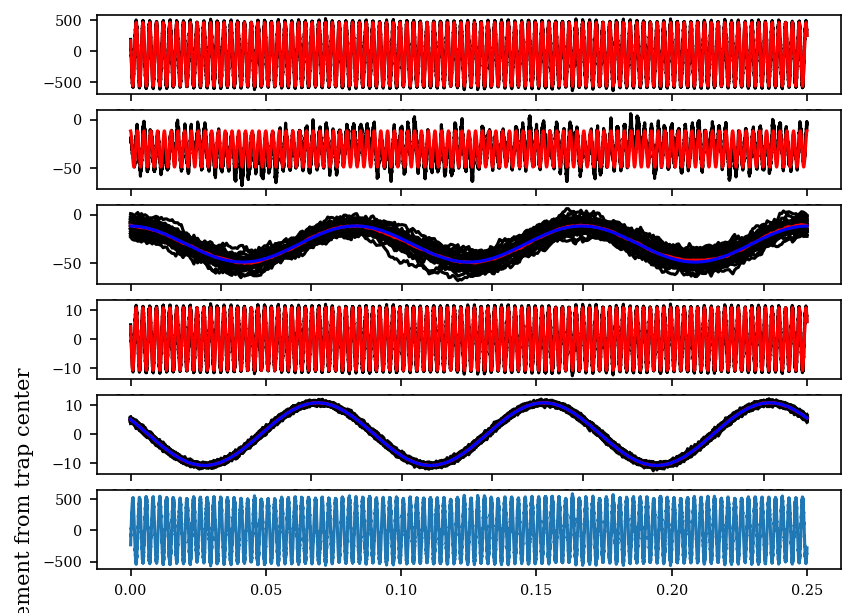

FG frequency:  499.93241386653096
YDATA, Fitting all oscillations - frequency:  499.93241386653096 Amplitude: 15.602778587648496  and phase:  4.1298355784943785
YDATA, Fitting averaged oscillations - frequency:  499.93241386653096 Amplitude:  15.616417229503051  and phase:  4.172718874393624
FORCE, Fitting all oscillations - frequency:  499.93241386653096 Amplitude: 10.886722064297258  and phase:  2.9930797656940036
FORCE, Fitting averaged oscillations - frequency:  499.93241386653096 Amplitude:  -10.88360507782766  and phase:  3.033809960147141


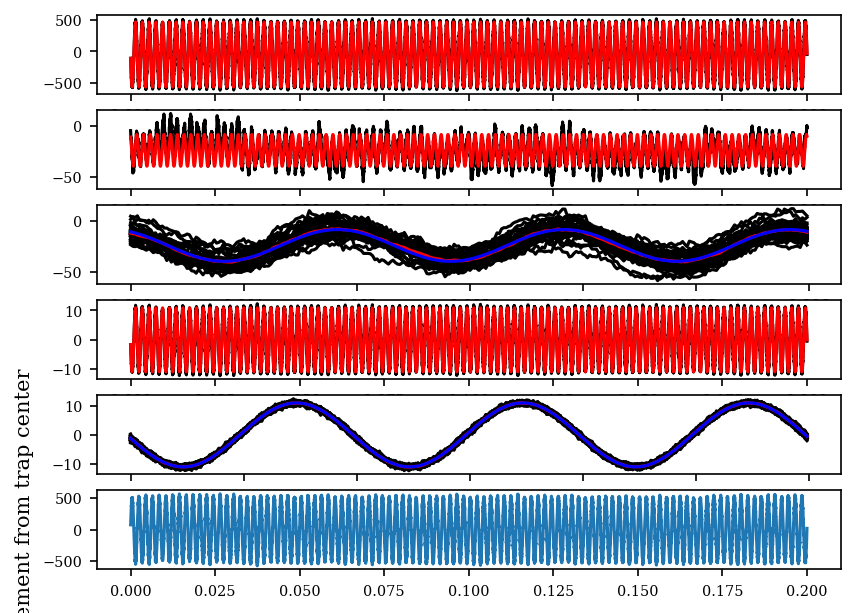

FG frequency:  599.9505090490063
YDATA, Fitting all oscillations - frequency:  599.9505090490063 Amplitude: 13.55237237872712  and phase:  0.2133658164388367
YDATA, Fitting averaged oscillations - frequency:  599.9505090490063 Amplitude:  13.543276422924512  and phase:  0.23661407673733686
FORCE, Fitting all oscillations - frequency:  599.9505090490063 Amplitude: 10.908701614793282  and phase:  -0.9469240003242086
FORCE, Fitting averaged oscillations - frequency:  599.9505090490063 Amplitude:  10.906891515736193  and phase:  -0.9219531800713534


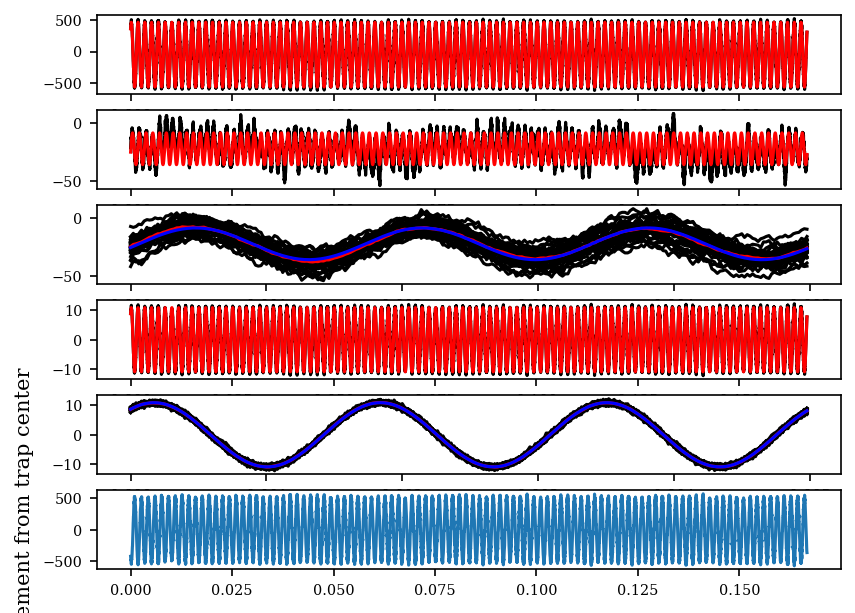

FG frequency:  699.9771040496097
YDATA, Fitting all oscillations - frequency:  699.9771040496097 Amplitude: 12.120450320842577  and phase:  3.84013916817067
YDATA, Fitting averaged oscillations - frequency:  699.9771040496097 Amplitude:  11.833323036116374  and phase:  4.245968054140757
FORCE, Fitting all oscillations - frequency:  699.9771040496097 Amplitude: 10.934010547674905  and phase:  2.63152330671483
FORCE, Fitting averaged oscillations - frequency:  699.9771040496097 Amplitude:  -10.606935908567241  and phase:  3.04351244785871


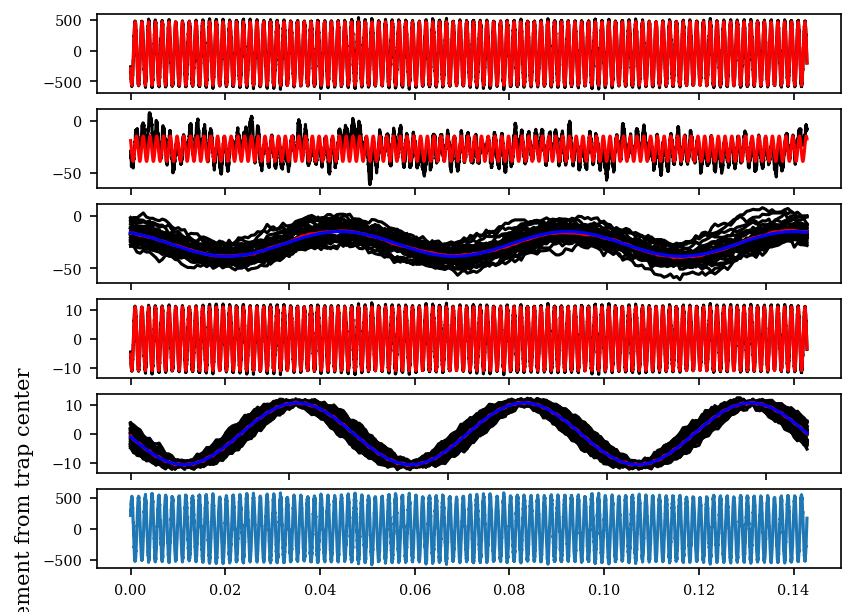

FG frequency:  799.8128014853542
YDATA, Fitting all oscillations - frequency:  799.8128014853542 Amplitude: 10.720882002975527  and phase:  2.9740390173611764
YDATA, Fitting averaged oscillations - frequency:  799.8128014853542 Amplitude:  9.187857518673868  and phase:  3.8493188167632986
FORCE, Fitting all oscillations - frequency:  799.8128014853542 Amplitude: -10.953797707758183  and phase:  1.700254432772687
FORCE, Fitting averaged oscillations - frequency:  799.8128014853542 Amplitude:  9.531905582196897  and phase:  2.5751900107291776


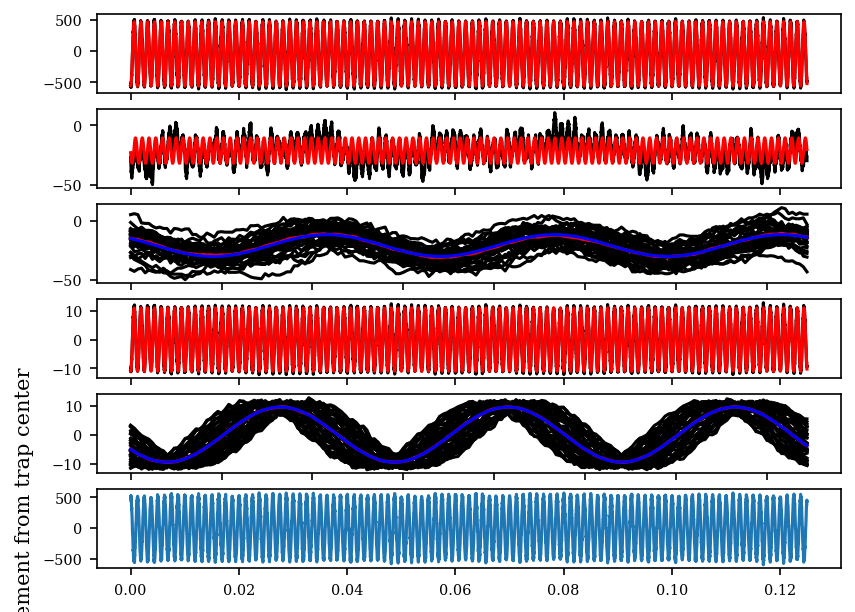

FG frequency:  899.8391971794215
YDATA, Fitting all oscillations - frequency:  899.8391971794215 Amplitude: 9.8491697649216  and phase:  0.20845714538668977
YDATA, Fitting averaged oscillations - frequency:  899.8391971794215 Amplitude:  7.4220456332781035  and phase:  1.4775389035618633
FORCE, Fitting all oscillations - frequency:  899.8391971794215 Amplitude: 10.967578912273261  and phase:  -1.0525153917482604
FORCE, Fitting averaged oscillations - frequency:  899.8391971794215 Amplitude:  8.13537056948333  and phase:  0.20823254416049228


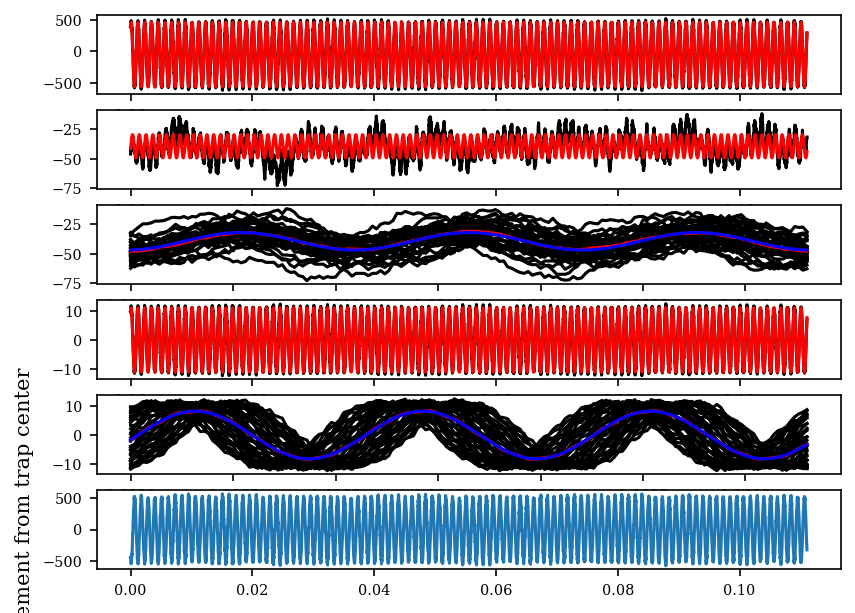

FG frequency:  999.8595212442217
YDATA, Fitting all oscillations - frequency:  999.8595212442217 Amplitude: 9.643465797572711  and phase:  4.659932381446002
YDATA, Fitting averaged oscillations - frequency:  999.8595212442217 Amplitude:  9.633650535521332  and phase:  4.703903711868636
FORCE, Fitting all oscillations - frequency:  999.8595212442217 Amplitude: 10.994206195455273  and phase:  -2.9968970019263717
FORCE, Fitting averaged oscillations - frequency:  999.8595212442217 Amplitude:  10.990917180948221  and phase:  -2.9545580143660994


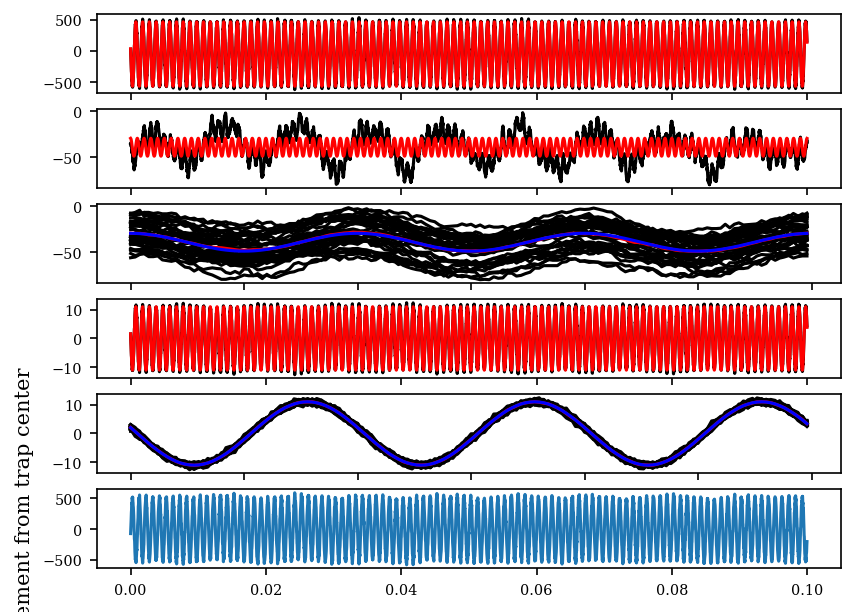

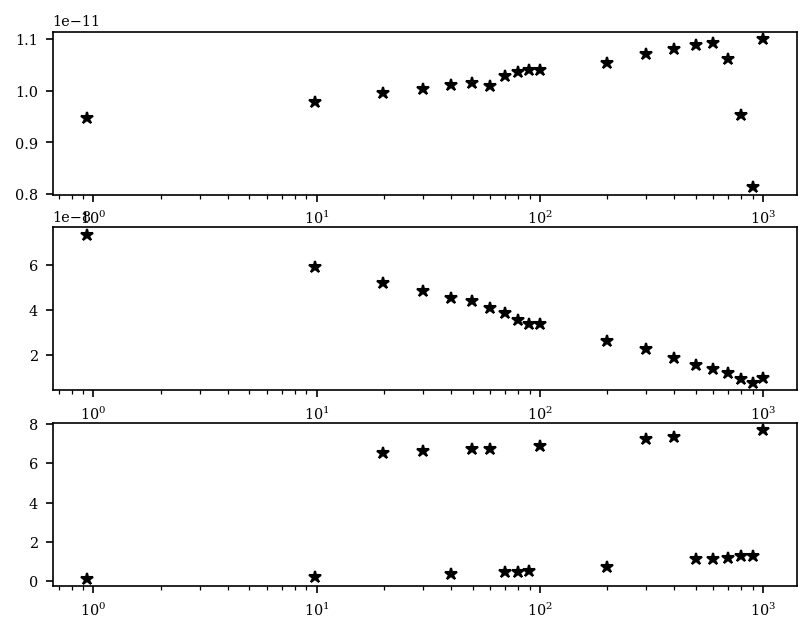

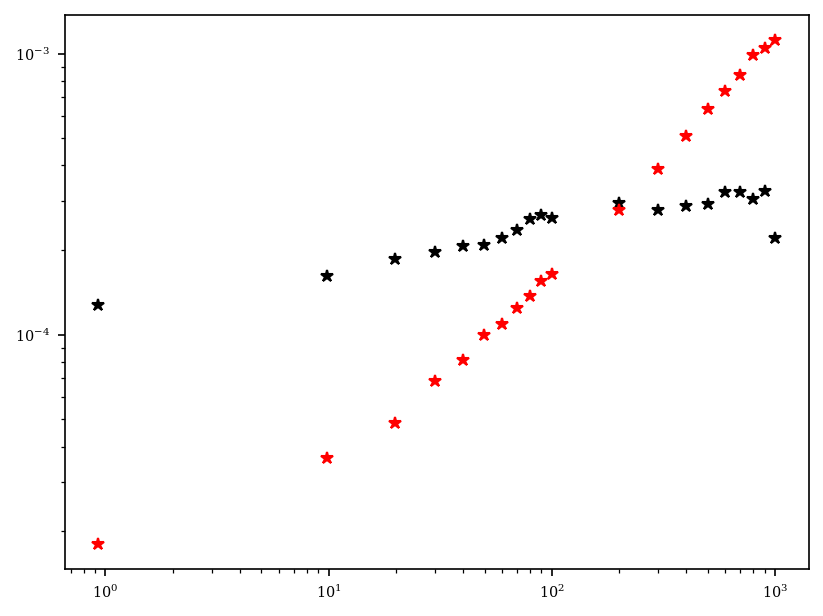

In [ ]:
pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/241003/'

plt.figure()
frequencies = np.array([])
for i in range(0, 160):
  x, y, sumsignal, fg= loaddataquiet('bead4a/bead4a_', i, i+1, 0)
  t = np.arange(0, len(yb)/fs, 1/fs)
  Y = fft(fg)
  N = len(Y)
  n = np.arange(N)
  T = N/fs
  freq = n/T
  index = (freq>0.1)*(freq<20000)
  freqsec = freq[index]
  Ysec = np.abs(Y[index])
  frequencies = np.append(frequencies, freqsec[Ysec == np.max(Ysec)])
plt.plot(frequencies, 'k*')

frequenciesold = frequencies[0]

# Try fitting five periods to a sine wave
from scipy import optimize
def sinefit(t, A, C, D, omega):
    return np.abs(A) * np.sin(omega*t - C)+D
def sinefit2(freqoscil):
  def func(t,*p):
    return np.abs(p[0]) * np.sin(freqoscil*t - p[1])+p[2]
  return func

plt.show()

# Let's say we want 50 oscillations for our fitting
# time = 50/frequency = the number of data files
# but we can't do this for 1 HZ...because we only have 15 files...stick with 10 oscillations

freqlist = np.array([])
Fnot = np.array([])
ynot = np.array([])
delta = np.array([])
for i in range(0, len(frequencies)):

  if frequencies[i] < 30:
    Nfit = 10
  else:
    Nfit = 100

  if (i == 0) or (frequencies[i]-frequenciesold > 1):

    # Start by fitting the function generator to get the frequency of oscillation
    if i == 0:
      x, y, sumsignal, fg= loaddataquiet('bead4a/bead4a_', 0, 15, 0)
    else:
      x, y, sumsignal, fg= loaddataquiet('bead4a/bead4a_', i+1, i+int(100/frequencies[i])+2, 0)
    times = np.arange(0, dt*len(y), dt)
    plt.figure()
    plt.subplot(6, 1, 1)
    xdata = t[0:int(Nfit*50000/frequencies[i])]
    OTdata = a*fg[0:int(Nfit*50000/frequencies[i])]+b
    plt.plot(xdata, OTdata, 'k')
    params, params_covariance = optimize.curve_fit(sinefit, xdata, OTdata, p0=[np.std(OTdata)*np.sqrt(2), np.pi, 0, 2*np.pi*frequencies[i]])
    phase = params[1]
    #if phase < 0:
    #  phase = phase+2*np.pi
    print('FG frequency: ', params[3]/(2*np.pi))# , 'and phase', phase)
    freqlist = np.append(freqlist, params[3]/(2*np.pi))
    #fgphase = params[1]
    plt.plot(xdata, sinefit(xdata, *params), 'r-')

    # Now calculate the force exerted on the bead
    ydata = y[0:int(Nfit*50000/frequencies[i])]*1e9
    Fcurve = -(ky / 1e-12 * 1e-9) * ((ydata-np.mean(ydata)) - (OTdata-np.mean(OTdata)))  # in pN

    # Fit the ydata
    Noscil = 3
    plt.subplot(6, 1, 2)
    plt.plot(xdata, ydata, 'k')
    freqoscil = params[3]/(2*np.pi)
    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), xdata, ydata, p0=[np.std(ydata)*np.sqrt(2), np.pi, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.plot(xdata, sinefit(xdata, *params), 'r-')
    phase = params[1]
    print('YDATA, Fitting all oscillations - frequency: ', params[3]/(2*np.pi), 'Amplitude:', params[0], ' and phase: ', phase)
    aveydata = np.zeros(int((Noscil/freqoscil)/dt))
    count = 0
    for j in range(0, len(ydata), int((Noscil/freqoscil)/dt)):
      if len(ydata[j:j+int((Noscil/freqoscil)/dt)]) == len(aveydata):
        count = count+1
        aveydata = aveydata + ydata[j:j+int((Noscil/freqoscil)/dt)]
        plt.subplot(6, 1, 3)
        times = dt*np.arange(0, len(ydata[j:j+int((Noscil/freqoscil)/dt)]), 1)
        plt.plot(times, ydata[j:j+int((Noscil/freqoscil)/dt)], 'k-')
    aveydata = aveydata/count
    plt.plot(times, aveydata, 'r')
    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveydata, p0=[np.std(ydata)*np.sqrt(2), phase, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.plot(times, sinefit(times, *params), 'b-')
    frequenciesold = frequencies[i]
    phase = params[1]
    print('YDATA, Fitting averaged oscillations - frequency: ', params[3]/(2*np.pi), 'Amplitude: ', params[0], ' and phase: ', phase)
    yphase = phase
    ynot = np.append(ynot, params[0]*1e-9)

   # Fit the forces
    plt.subplot(6, 1, 4)
    plt.plot(xdata, Fcurve, 'k')
    freqoscil = params[3]/(2*np.pi)
    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), xdata, Fcurve, p0=[np.std(Fcurve)*np.sqrt(2), 0, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.plot(xdata, sinefit(xdata, *params), 'r-')
    print('FORCE, Fitting all oscillations - frequency: ', params[3]/(2*np.pi), 'Amplitude:', params[0], ' and phase: ', params[1])
    aveFdata = np.zeros(int((Noscil/freqoscil)/dt))
    count = 0
    for j in range(0, len(Fcurve), int((Noscil/freqoscil)/dt)):
      if len(Fcurve[j:j+int((Noscil/freqoscil)/dt)]) == len(aveFdata):
        count = count+1
        aveFdata = aveFdata + Fcurve[j:j+int((Noscil/freqoscil)/dt)]
        plt.subplot(6, 1, 5)
        times = dt*np.arange(0, len(Fcurve[j:j+int((Noscil/freqoscil)/dt)]), 1)
        plt.plot(times, Fcurve[j:j+int((Noscil/freqoscil)/dt)], 'k-')
    aveFdata = aveFdata/count
    plt.plot(times, aveFdata, 'r')
    params, params_covariance = optimize.curve_fit(sinefit2(2*np.pi*freqoscil), times, aveFdata, p0=[np.std(ydata)*np.sqrt(2), 0, 0])
    params = np.append(params, 2*np.pi*freqoscil)
    plt.plot(times, sinefit(times, *params), 'b-')
    frequenciesold = frequencies[i]
    print('FORCE, Fitting averaged oscillations - frequency: ', params[3]/(2*np.pi), 'Amplitude: ', params[0], ' and phase: ', params[1])
    plt.subplot(6, 1, 6)
    plt.plot(t[0:int(Nfit*50000/frequencies[i])], (ydata-np.mean(ydata)) - (OTdata-np.mean(OTdata)))
    plt.ylabel('displacement from trap center')

    deltatemp = yphase-params[1]
    if deltatemp<0:
      deltatemp = deltatemp+2*np.pi
    delta = np.append(delta, deltatemp)

    Fnot = np.append(Fnot, params[0]*1e-12)

    plt.show()

plt.figure()
plt.subplot(3, 1, 1)
plt.semilogx(freqlist, np.abs(Fnot), 'k*')
plt.subplot(3, 1, 2)
plt.semilogx(freqlist, np.abs(ynot), 'k*')
plt.subplot(3, 1, 3)
plt.semilogx(freqlist, delta, 'k*')

plt.figure()
plt.loglog(freqlist, np.abs(Fnot/ynot)*np.cos(delta), 'k*')
plt.loglog(freqlist, np.abs(Fnot/ynot)*np.sin(delta), 'r*')

Gprimebig = np.abs(Fnot/ynot)*np.cos(delta)
Gprimeprimebig = np.abs(Fnot/ynot)*np.sin(delta)
freqlistbig = freqlist

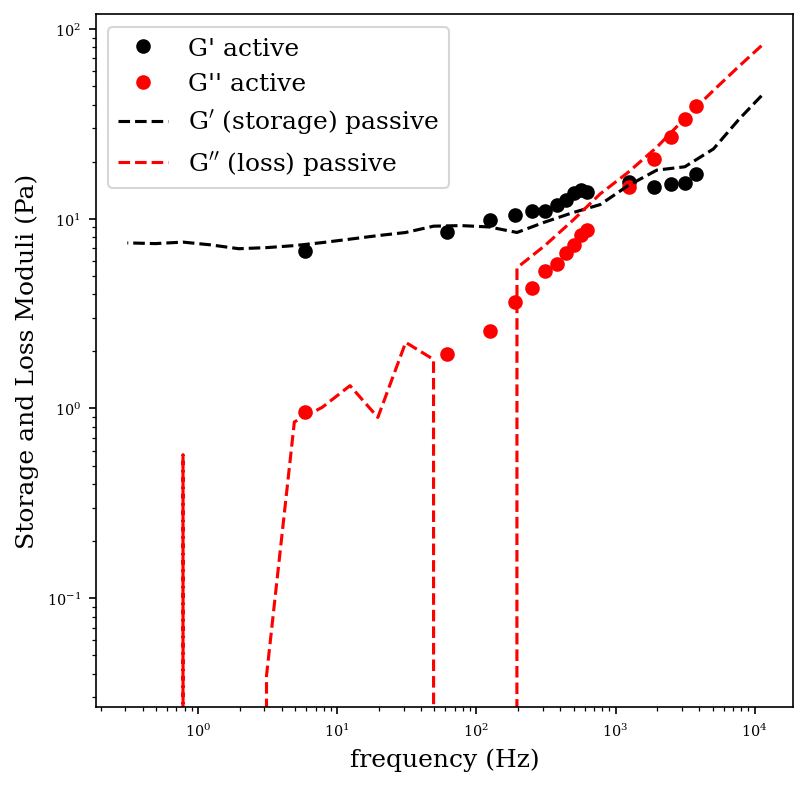

In [ ]:
Gprime = np.abs(Fnot/(6*np.pi*(1e-6)*ynot))*np.cos(delta)
Gprimeprime = np.abs(Fnot/(6*np.pi*(1e-6)*ynot))*np.sin(delta)

index = (Gprime>0.1)*(freqlist<610)
plt.figure(figsize = (6, 6))
plt.loglog(2*np.pi*freqlist[index], Gprime[index], 'ko', label = 'G\' active')
plt.loglog(2*np.pi*freqlist[index], Gprimeprime[index], 'ro', label = 'G\'\' active')

plt.loglog(omega_list[1:], Greals2, 'k--', label='G$^\prime$ (storage) passive')
plt.loglog(omega_list[1:], Gimags2, 'r--', label='G$^{\prime\prime}$ (loss) passive')


plt.xlabel('frequency (Hz)', fontsize = 12)
plt.ylabel('Storage and Loss Moduli (Pa)', fontsize = 12)
plt.legend(fontsize = 12)


#Bead1p passive microrheology

499999
999998


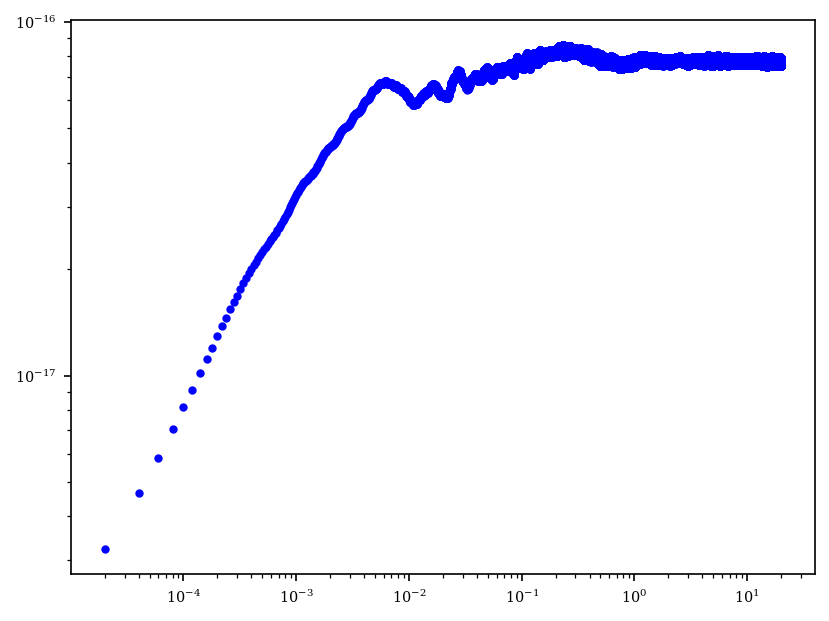

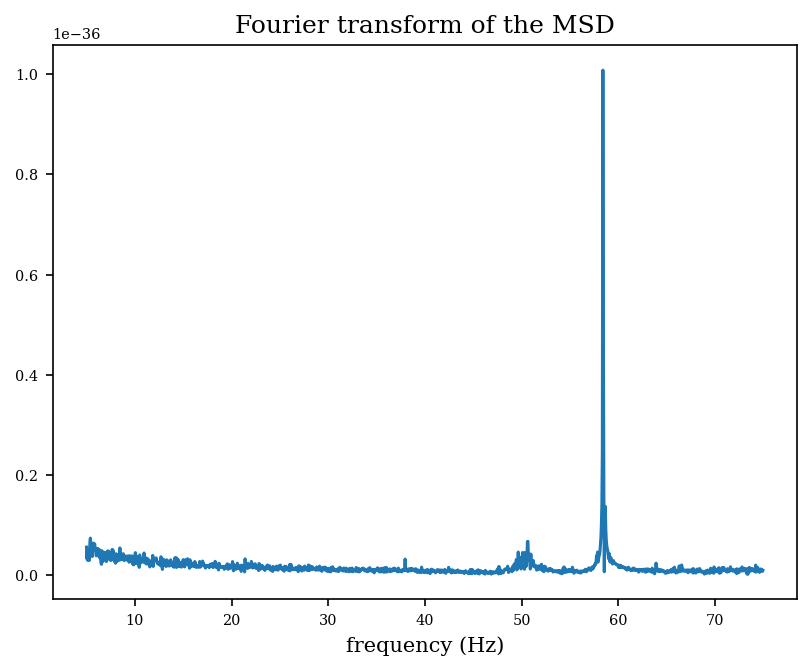

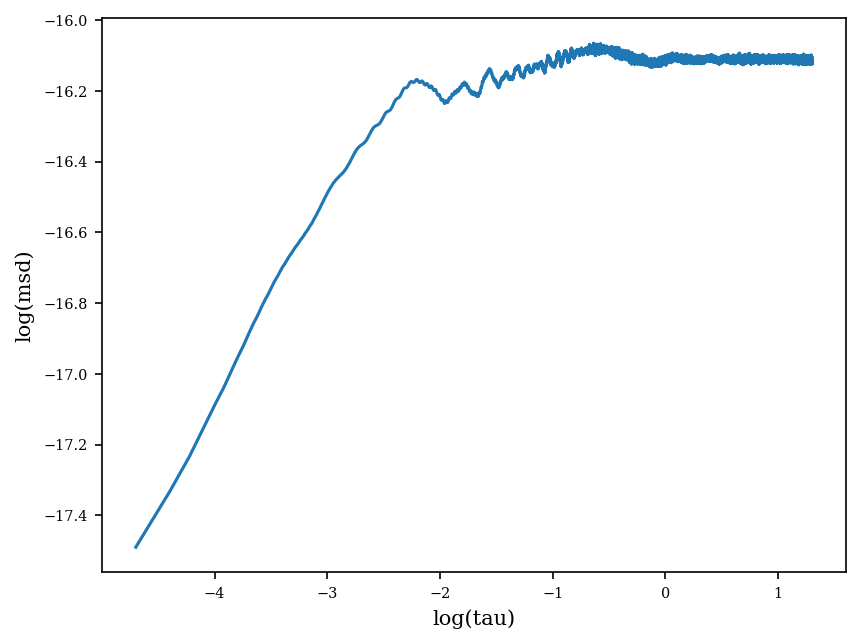

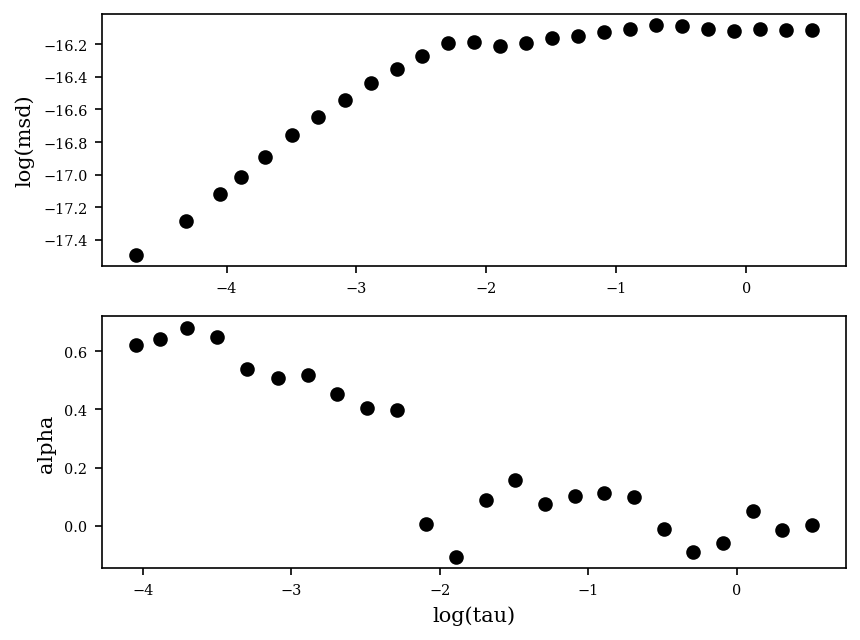

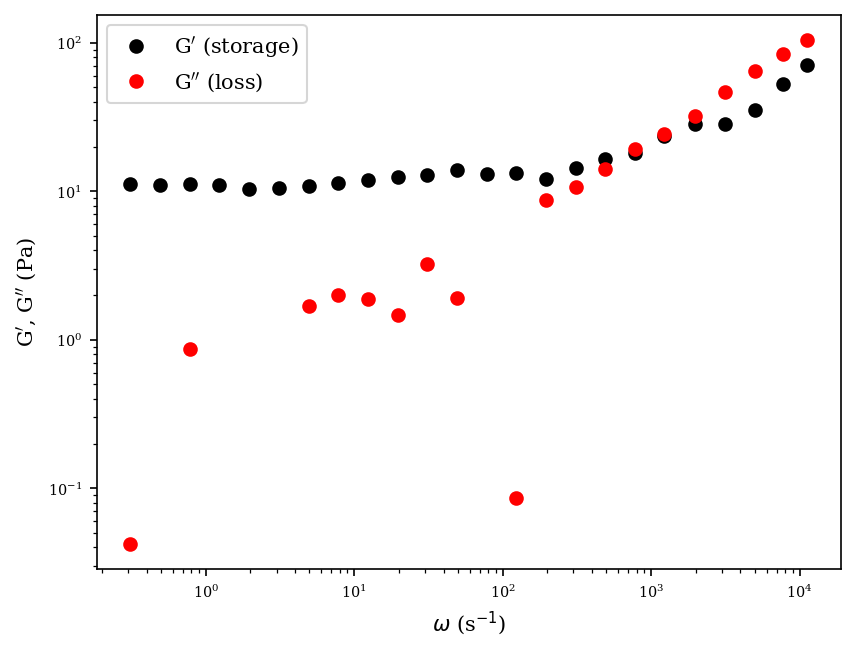

In [ ]:
from scipy import signal

pathname = '/content/drive/My Drive/Altman Lab Articles and Protocols/UPLOADED DATA/debois/241003/'

def calcmsd2(x, y, analysislength, msdlength):

    dt = 1/50000
    fs = 50000
  # Select data to analyze MSD and fourier transform
    xdata = x[0:int(analysislength/dt)]
    ydata = y[0:int(analysislength/dt)]


    sos = signal.butter(10, 1, 'hp', fs=50000, output='sos')
    xdata = signal.sosfilt(sos, xdata)
    ydata = signal.sosfilt(sos, ydata)


    msdvalues = msd_fft(xdata, ydata)
    tautemp = msdvalues.tau
    msdtemp = msdvalues.msd
    msdvalues.tau = tautemp[0:int(msdlength/dt)]
    msdvalues.msd = msdtemp[0:int(msdlength/dt)]

    plt.figure()
    plt.loglog(msdvalues.tau[1:int(msdlength/(dt))], msdvalues.msd[1:int(msdlength/(dt))], 'b.', label = 'Bead in the Optical Trap')
    plt.figure()
    msddata = np.array(msdvalues.msd[1:int(msdlength/dt)]) / (1e18)
    N = len(msddata)
    T = 1/fs
    yf = fft(msddata)
    xf = fftfreq(N, T)[:N//2]

    print(len(xf))
    print(len(yf))
    plt.plot(xf[100:1500], 2.0/N * np.abs(yf[100:1500]))
    plt.xlabel('frequency (Hz)')
    plt.title('Fourier transform of the MSD')
    plt.show()
    return msdvalues

msdave = np.zeros(int(0.1*fs))
x, y, sumsignal, fg= loaddataquiet('bead2p/bead2p_', 0, 120, 0) # output is in m

msdvalues = calcmsd2(x, y, 120, 20) # Analyze the first 130 s, calculating the MSD for a maximum tau fo 20 s
msdvaluesdata1 =  msdvalues
# initialize a list
alpha_list = []
omega_list = []
logtau_list = []
logmsd_list = []
tau_list = []
msd_list = []
analysislength = 20

def linear_alpha(x,m,b):
    return m*x+b
#fitting this line to the slope of the range of eleven different values of MSD data (log(tau)vs log(msd)) using an analytical method
#for i in range(6,np.int(msdlength*fs)-5): full range


N = 0.2 #iteration step

logmsd = np.log10(msdvaluesdata1.msd[:int(analysislength*fs)])
logtau = np.log10(msdvaluesdata1.tau[:int(analysislength*fs)])
msd = (msdvaluesdata1.msd[:int(analysislength*fs)])
tau = (msdvaluesdata1.tau[:int(analysislength*fs)])

plt.figure()
plt.plot(logtau, logmsd)
plt.xlabel('log(tau)')
plt.ylabel('log(msd)')
plt.show()

for i in np.arange(-5, np.log10(5)-N, N):

    index = (logtau > i) * (logtau <i+N)
    logmsdsel = (logmsd[index])
    logtausel = (logtau[index])

    msdsel = msd[index]
    tausel = tau[index]

    n = len(tausel)

    logmsd_list.append(np.mean(logmsdsel))
    logtau_list.append(np.mean(logtausel))
    msd_list.append(np.mean(msdsel))
    tau_list.append(np.mean(tausel))

    omega_list.append(1/(10**(logtau_list[-1])))

    # METHOD 2 for calculating the slope
    if len(logmsd_list)>1:
        slope = (logmsd_list[-1]-logmsd_list[-2])/(logtau_list[-1]-logtau_list[-2])
    else:
        slope = float("NaN")

    alpha_list.append(slope)

# DAVID: This plot shows us ln(msd) vs ln(tau) on the top.  The alpha curve on the bottom should be the slope of this curve
#   You may notice that the slope looks like it was calculated really well for the first part of the curve, but as we
#   move to the right, and the slope approaches zero, our calculation of the slope is  noisy
plt.figure()
plt.subplot(2, 1, 1)
plt.plot(logtau_list, logmsd_list, 'ko')
plt.ylabel('log(msd)')

plt.subplot(2, 1, 2)
plt.plot(logtau_list, alpha_list, 'ko')
plt.ylabel('alpha')
plt.xlabel('log(tau)')
plt.show()

logtau_list_data = logtau_list
logmsd_list_data = logmsd_list

#CONSTANTS
d = 2 # number of dimensions (x and y)
T = 293.15 # room temp --> 20 celcius = 293.15 Kelvin
K_B = 1.3806e-23 # Boltzmann Constant J/K
radius = (2.0e-6)/2  # radius of the bead, we used 2.01 um diameter beads, multiplied by 10^-6 to get in meters (m)
kBT = 4.11e-21 # room temp * Boltzmann Const.

#lists
Greals2 = [] #list for all G'
Gimags2 = [] #List for all G''
Gstar_primes2 = []
Gstar_Dprimes2 = []
Gstars2 = []
#omegafinal2 = [];
for i in range (1, len(alpha_list)):
    #ω = 1 / tau[i]
    #msd = msd[i]
    #αω = αω[i-1]
    gamma = (0.457*(1+alpha_list[i])**2) - (1.36*(1+alpha_list[i])) + 1.9 #approx value from Mason 2000 p.373 below eqn. 8
    Gstar2 = abs((2*d*K_B*T) / (6*np.pi*radius*msd_list[i]*gamma))
    Gstars2.append(Gstar2)
    Gstar_prime2 = Gstar2 * np.cos((np.pi*alpha_list[i])/2)
    Gstar_Dprime2 = Gstar2 * np.sin((np.pi*alpha_list[i])/2)
    Gstar_primes2.append(Gstar_prime2)
    Gstar_Dprimes2.append(Gstar_Dprime2)

    ktrap = (kx+ky)/2
    offset =  ktrap/(6*np.pi*(1e-6))

    # DAVID: you need to subtract k / (6*pi*a) (kept in SI units)
    Greal2 = Gstar_prime2 #- offset # G' is subtracted by stiffness of the trap because it is the real component
    Gimag2 = Gstar_Dprime2
    Greals2.append(Greal2)
    Gimags2.append(Gimag2)
    #omegafinal2.append(1/msdvaluesdata1.tau[i])

plt.rc('font', family='serif')
plt.rc('xtick', labelsize='x-small')
plt.rc('ytick', labelsize='x-small')
plt.rcParams['figure.dpi']= 150

Greals2 = np.array(Greals2)
Gimags2 = np.array(Gimags2)

plt.figure()
plt.loglog(omega_list[1:], Greals2, 'ko', label='G$^\prime$ (storage)')
plt.loglog(omega_list[1:], Gimags2, 'ro', label='G$^{\prime\prime}$ (loss)')
#plt.loglog(omega_list[1:], np.ones(len(omega_list[1:]))*((kx+ky)/2)/(6*np.pi*1e-6), 'g-')
#plt.loglog(omega_list[1:], np.ones(len(omega_list[1:]))*eta*omega_list[1:], 'g-')

#plt.loglog(omega_list[1:], offset*np.ones(len(omega_list)-1), '--')
plt.xlabel(r'$\omega$ (s$^{-1}$)')
plt.ylabel(r'G$^\prime$, G$^{\prime\prime}$ (Pa)')
plt.legend()
plt.show()

Greals2_data = Greals2
Gimags2_data = Gimags2
omega_list_data = omega_list

